# pybvh Feature Gallery

One **picture per feature**, designed so the figure *is* the explanation: operations and geometric descriptors are drawn in 3D on the skeleton, dynamic descriptors are annotated on the signals they summarize, and SE(3) transforms are drawn as coordinate frames. Where a real pose would obscure the idea, a small synthetic example is used instead. Sections 1-5 cover the core library (viewing, concepts, transforms, skeleton ops, export); sections 6-12 the motion-descriptor layer introduced in pybvh 0.8.0.

Each cell shows the **feature call** (`bvh.mirror()`, `bvh.curvature(...)`, …); where a figure needs extra annotation, the matplotlib lives in the companion module **`gallery_plots.py`** (imported as `gp`), so the notebook stays about the features, not the plumbing.

API reference for everything shown here: [Bvh class](https://victors-67.github.io/pybvh/api/bvh/) · [geometry](https://victors-67.github.io/pybvh/api/geometry/) · [analysis](https://victors-67.github.io/pybvh/api/analysis/) · [rotations & SE(3)](https://victors-67.github.io/pybvh/api/rotations/) · [transforms](https://victors-67.github.io/pybvh/api/transforms/) · [signal](https://victors-67.github.io/pybvh/api/signal/)

Sections: **1** load & see · **2** core concepts, drawn · **3** transforms & augmentation · **4** skeleton & frame ops · **5** contacts & feature export · **6** geometry (relations) · **7** geometry (bounding & centre of mass) · **8** geometry (trajectory) · **9** analysis (dynamics & gait) · **10** SE(3) rigid transforms · **11** signal utilities · **12** scale.

*If your viewer fails to render any figure or clip, [the notebook on nbviewer](https://nbviewer.org/github/VictorS-67/pybvh/blob/main/gallery/feature_gallery.ipynb) renders everything.*

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np

import pybvh
from pybvh import analysis, geometry, rotations, signal

import gallery_plots as gp

REPO = Path.cwd().parent if Path.cwd().name in ("tutorials", "gallery") else Path.cwd()
bvh = pybvh.read_bvh_file(REPO / "bvh_data" / "bvh_test1.bvh")
pos = bvh.node_positions()                  # (F, N, 3)
F = bvh.frame_count
dt = bvh.frame_time
t = np.arange(F) * dt
FRAME = F // 2                              # a representative pose
P = pos[FRAME]

def idx(name):
    return bvh.index(name, space="node")

print(bvh)

24 joints, 75 frames at 30.0 fps (frame_time=0.033333s, from bvh_test1.bvh)


**Where the drawing lives & adjusting the view.** Every figure is built by a `gp.fig_*` function in `gallery_plots.py`. To re-aim the 3D camera for *all* figures, set `gp.VIEW_ELEV` / `gp.VIEW_AZIM`; a handful of figures pin their own angle inside their function (edit it there). The skeleton/triad/equal-box helpers also live in that module.

## 1 · Load & see

The test clip used through most of this gallery, rendered with **`bvh.render`** to a GIF committed beside this notebook (resampled to the GIF's 20 fps so it plays in real time). The markdown cell below displays the committed file rather than the cell embedding the clip as an output: GitHub's notebook renderer shows `image/png` outputs but silently drops `image/gif` ones, so an embedded clip would be invisible exactly where most readers meet the library. For an interactive scrubber instead, use `bvh.play()` in a live kernel.

In [2]:
seq_gif = gp.motion_clip_gif(bvh)   # renders the clip itself — no single feature value to surface

![the test clip, rendered by bvh.render with the front camera](https://raw.githubusercontent.com/VictorS-67/pybvh/main/gallery/feature_gallery_seq.gif)

**`plot_rest_pose`** & **`plot_frame`** — the two static snapshots: the rest pose (all joint angles zero, offsets only — the first thing to check on a new file) and any animation frame, with `camera="front"/"side"/"top"` or a custom `(azimuth, elevation)` tuple. Multi-skeleton comparisons use the same functions from `pybvh.bvhplot` with a list, as later sections show.

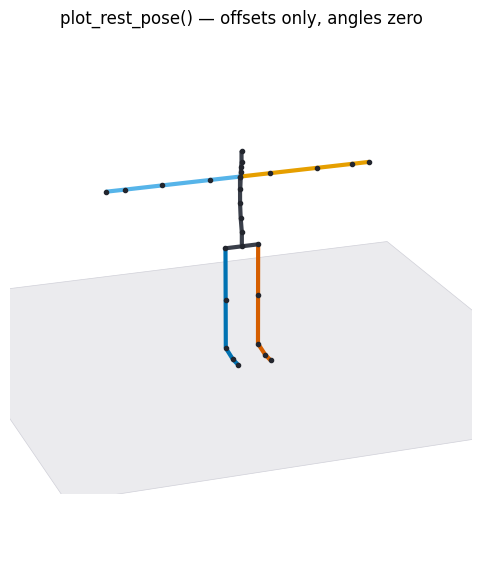

In [3]:
fig, ax = bvh.plot_rest_pose()
ax.set_title("plot_rest_pose() — offsets only, angles zero");

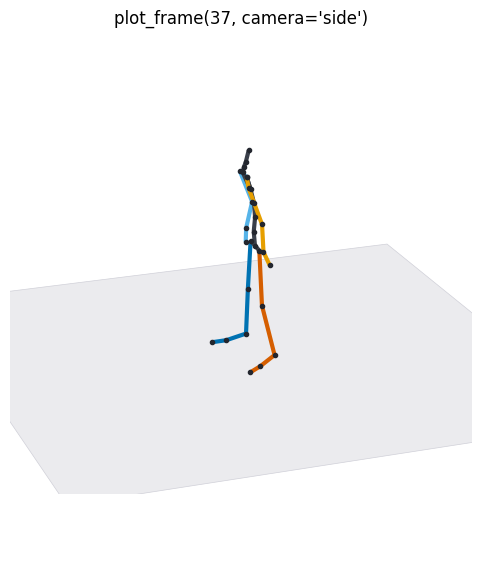

In [4]:
fig, ax = bvh.plot_frame(frame=FRAME, camera="side")
ax.set_title(f"plot_frame({FRAME}, camera='side')");

**`plot_sequence`** — the motion-paper still: equidistantly sampled poses in one figure, lightness encoding time (lighter = earlier), the root's path dashed on the floor. `layout="offset"` (default) places poses at their world positions, so locomotion reads left to right — shown on **real walking mocap** (CMU subject 12, *data from [mocap.cs.cmu.edu](http://mocap.cs.cmu.edu)*; sections 2, 5 and 9 reuse this clip). `layout="overlay"` superimposes root-centred poses instead, the right mode for in-place motion.

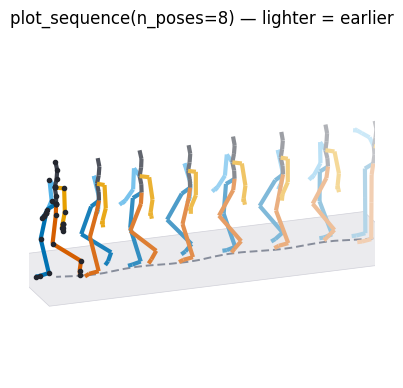

In [5]:
walk = pybvh.read_bvh_file(REPO / "bvh_data" / "cmu_12_01_walk.bvh")
fig, ax = walk.plot_sequence(n_poses=8)
ax.set_title("plot_sequence(n_poses=8) — lighter = earlier");

**`Style`** — every figure above uses the default preset `"paper"` (ground plane, per-chain colors, joint markers, axes off). All bvhplot functions take `style=`: a preset name — `"paper"`, `"debug"` (the single-blue-with-full-axes look, for coordinate inspection), `"dark"` (for slides and project pages) — or a `Style` instance overriding any field, e.g. `Style("paper", floor="checker", bone_width=4)`.

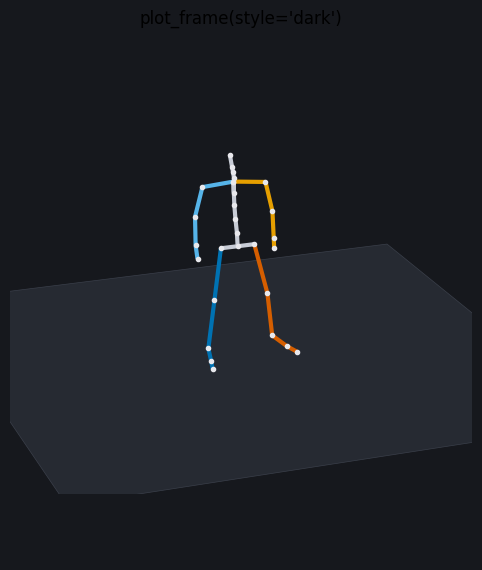

In [6]:
fig, ax = bvh.plot_frame(frame=FRAME, style="dark")
ax.set_title("plot_frame(style='dark')");

**The 0.9.0 default, and the look it replaced.** Left: `style="paper"`, applied by every bvhplot function unless told otherwise. Right: the same call with `style="debug"` — the pre-0.9.0 output, reproduced pixel-for-pixel, which is both the one-line migration for code written against the old default and the style to reach for when you need to read coordinates off the axes.

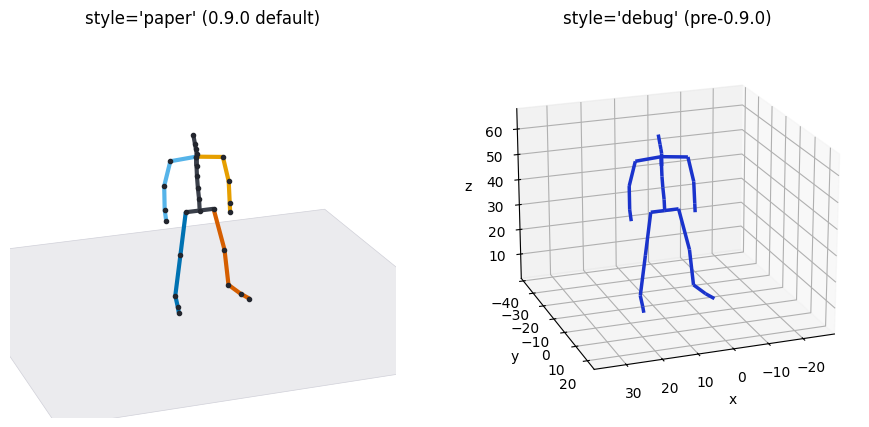

In [7]:
fig, (ax_paper, ax_debug) = gp.side_by_side_3d()
bvh.plot_frame(frame=FRAME, ax=ax_paper)                    # style="paper" is the default
bvh.plot_frame(frame=FRAME, style="debug", ax=ax_debug)
ax_paper.set_title("style='paper' (0.9.0 default)")
ax_debug.set_title("style='debug' (pre-0.9.0)");

**`plot_frame(backend="vedo")`** — the same pose as a shadowed 3D **capsule render**, computed fully offscreen (headless-safe) and returned as an `(H, W, 3)` uint8 RGB array: the publication-figure alternative to the matplotlib stick figure. `render(backend="vedo")` exports the same look as video.

(<Figure size 650x600 with 1 Axes>,
 <Axes: title={'center': "plot_frame(backend='vedo') — shadowed capsules"}>)

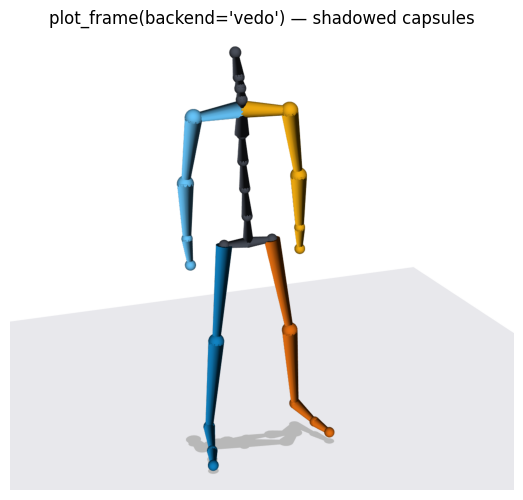

In [8]:
capsule_img = bvh.plot_frame(frame=FRAME, backend="vedo")
gp.fig_image(capsule_img, "plot_frame(backend='vedo') — shadowed capsules")

**`render(ghost=N, trajectory=True)`** — motion context inside a clip: `ghost=N` trails N faded copies of recent poses behind the live skeleton (spaced `Style.ghost_spacing` seconds apart, nearer ones darker) and `trajectory=True` draws the root's path on the floor as it goes, so a single frame of the video says where the motion has been. Two seconds of the walk clip, world-centered so the character travels across the frame:

In [9]:
ghost_gif = gp.ghost_trace_gif(walk[:240])

![two seconds of the walk clip rendered with ghost=3 and trajectory=True](https://raw.githubusercontent.com/VictorS-67/pybvh/main/gallery/feature_gallery_ghost.gif)

**`render(camera="turntable")`** — a full 360° orbit over the clip's duration, the standard way to show a motion from every side in one clip (here with `centered="skeleton"`, which pins the root so the orbit is the only motion in frame). Export knobs no still can show: `supersample` (2× anti-aliasing by default on the OpenCV backend), `codec="h264"` for mp4s that play in a browser, and `frame_counter=True` to stamp `Frame f/F` for review.

In [10]:
turntable_gif = gp.turntable_gif(walk)

![the walk clip with the camera orbiting a full 360 degrees](https://raw.githubusercontent.com/VictorS-67/pybvh/main/gallery/feature_gallery_turntable.gif)

## 2 · Core concepts, drawn

The ideas every pybvh user needs, one figure each. Full prose: the [Core Concepts](https://victors-67.github.io/pybvh/guide/core-concepts/) and [World Up](https://victors-67.github.io/pybvh/guide/world-up/) guides.

**`node_positions(centered=…)`** — the three coordinate modes for forward-kinematics output. Shown on the **walking clip** loaded in section 1 (travel makes the modes unmistakable). Same clip, same frame; the blue trail is the root's path over the whole clip. `"world"` keeps absolute file coordinates, `"first"` shifts the first frame's root over the origin (the character still travels), `"skeleton"` pins the root at the origin every frame — the trail collapses to a point: pose only, no travel.

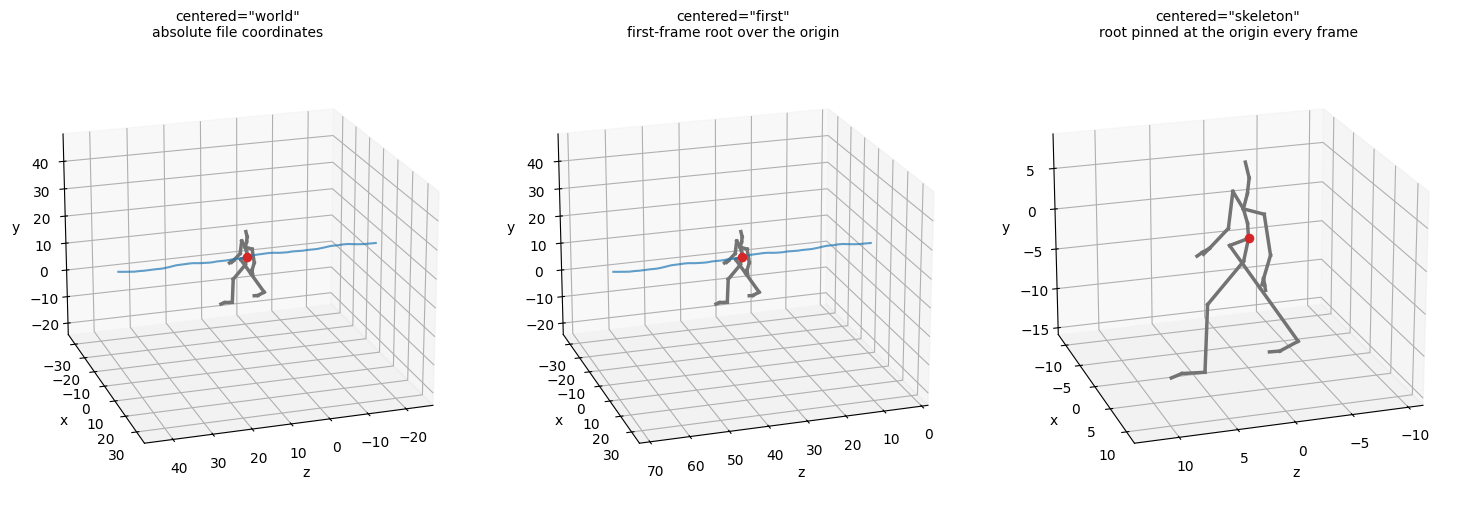

In [11]:
gp.fig_centered_modes(walk, walk.frame_count // 2)

**Why 6D exists** — a smooth rotation crossing the ±180° boundary, read out in three representations. Euler snaps from +180° to −180°; the canonical quaternion flips the sign of `z` where `w` crosses zero; 6D stays perfectly smooth — the property that makes it the default for neural-network outputs. (The other two Euler pitfalls — gimbal lock and order-dependence — are illustrated in [tutorial 3](https://victors-67.github.io/pybvh/tutorials/).)

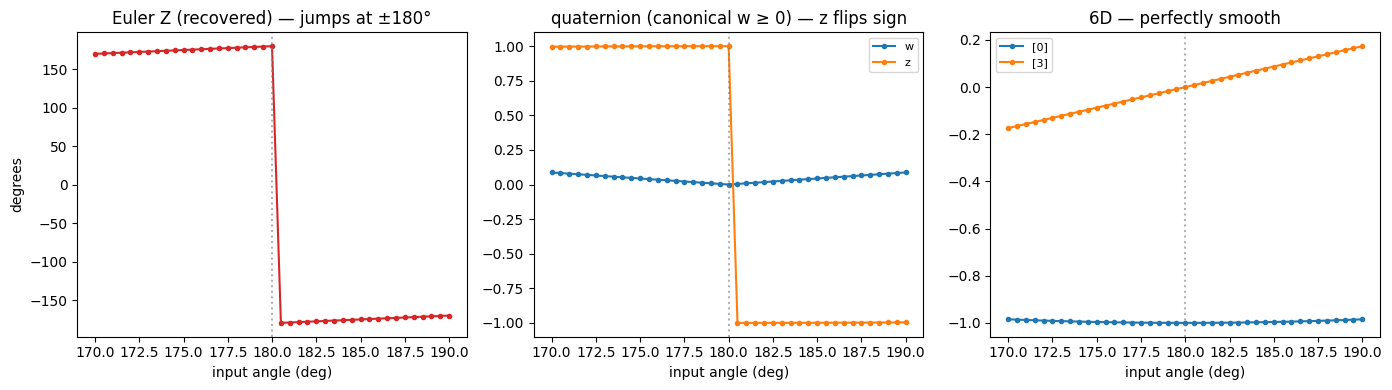

In [12]:
input_angles = np.linspace(170, 190, 41)
euler = np.zeros((41, 3))
euler[:, 0] = input_angles          # Z component in ZYX order
recovered = rotations.rotmat_to_euler(
    rotations.euler_to_rotmat(euler, "ZYX", degrees=True), "ZYX", degrees=True)
quats = rotations.euler_to_quat(euler, "ZYX", degrees=True)
rot6d = rotations.euler_to_rot6d(euler, "ZYX", degrees=True)
gp.fig_rotation_continuity(input_angles, recovered, quats, rot6d)

**`world_up` · `forward_at` · `left_at`** — the orientation triple. `world_up` is the gravity axis (auto-detected from the animation), `forward_at(frame)` is the character's facing direction at a frame (derived from the L/R joint pairs), and `left_at = world_up × forward` completes the right-handed frame. All three return signed-axis strings like `'+z'`.

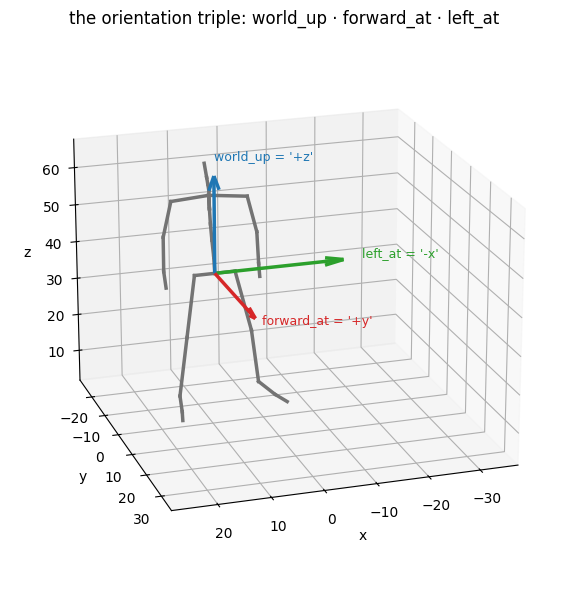

In [13]:
gp.fig_orientation_triad(bvh, FRAME)

**`reorient_world_up`** — files disagree on which axis is "up" (Y-up vs Z-up exporters). This rotates the whole scene into a chosen convention: the character looks identical, only the coordinates are rewritten. Here a Y-up file is unified to Z-up.

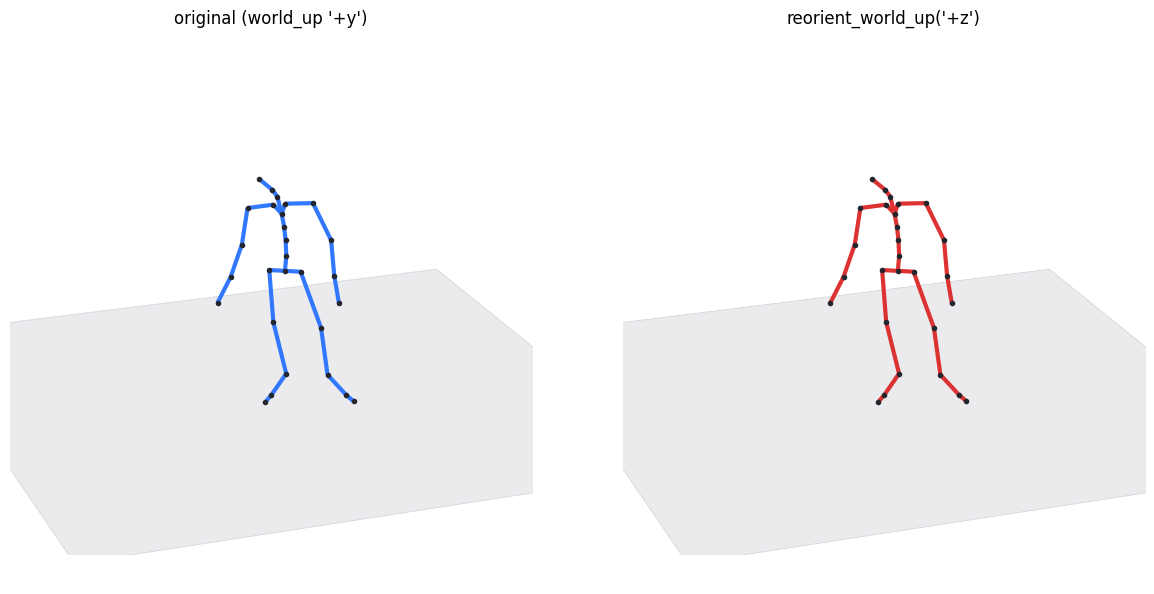

In [14]:
bvh_yup = pybvh.read_bvh_file(REPO / "bvh_data" / "bvh_test2.bvh")
pybvh.bvhplot.frame([bvh_yup, bvh_yup.reorient_world_up("+z")], frame=0,
                    labels=[f"original (world_up '{bvh_yup.world_up}')",
                            "reorient_world_up('+z')"]);

**`reorient_rest_up`** — some files author the rest pose in one convention but the animation in another (pybvh warns on load and trusts the animation). This rewrites the rest pose to match, compensating every joint rotation so the animated joint positions are unchanged to machine precision (printed below). `reorient_rest_forward` is the same idea for the facing axis.

max joint-position change: 2.1316282072803006e-14


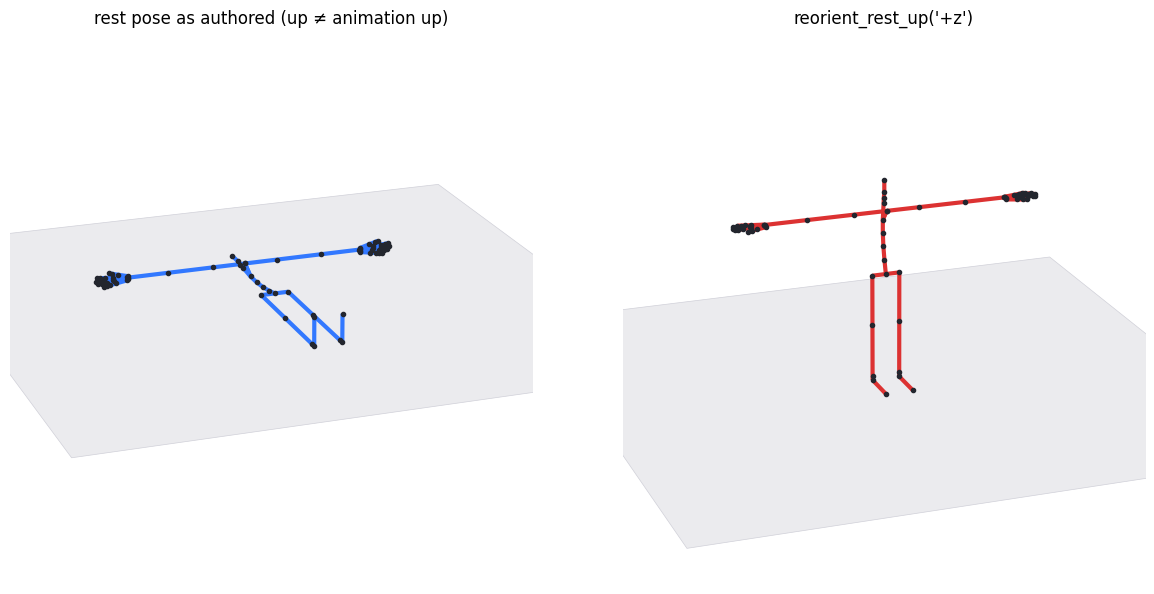

In [15]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # test3's rest/animation mismatch warns on load — that mismatch is the point
    bvh_mixed = pybvh.read_bvh_file(REPO / "bvh_data" / "bvh_test3.bvh")
bvh_fixedrest = bvh_mixed.reorient_rest_up("+z")
print("max joint-position change:",
      np.abs(bvh_mixed.node_positions() - bvh_fixedrest.node_positions()).max())
pybvh.bvhplot.rest_pose([bvh_mixed, bvh_fixedrest],
                        labels=["rest pose as authored (up ≠ animation up)",
                                "reorient_rest_up('+z')"]);

## 3 · Transforms & augmentation

The standard motion augmentations, each drawn as before/after. All exist as `Bvh` methods and as array-level `pybvh.transforms` functions, all accept a seeded `rng`, and each has a `random_*` variant that samples its parameter. Full prose: the [Data Augmentation guide](https://victors-67.github.io/pybvh/guide/augmentation/).

**`mirror`** — flips the motion left↔right. Not just an axis negation: the lateral axis is flipped **and** every `Left*`/`Right*` joint pair swaps data (both auto-detected), so the result stays anatomically possible.

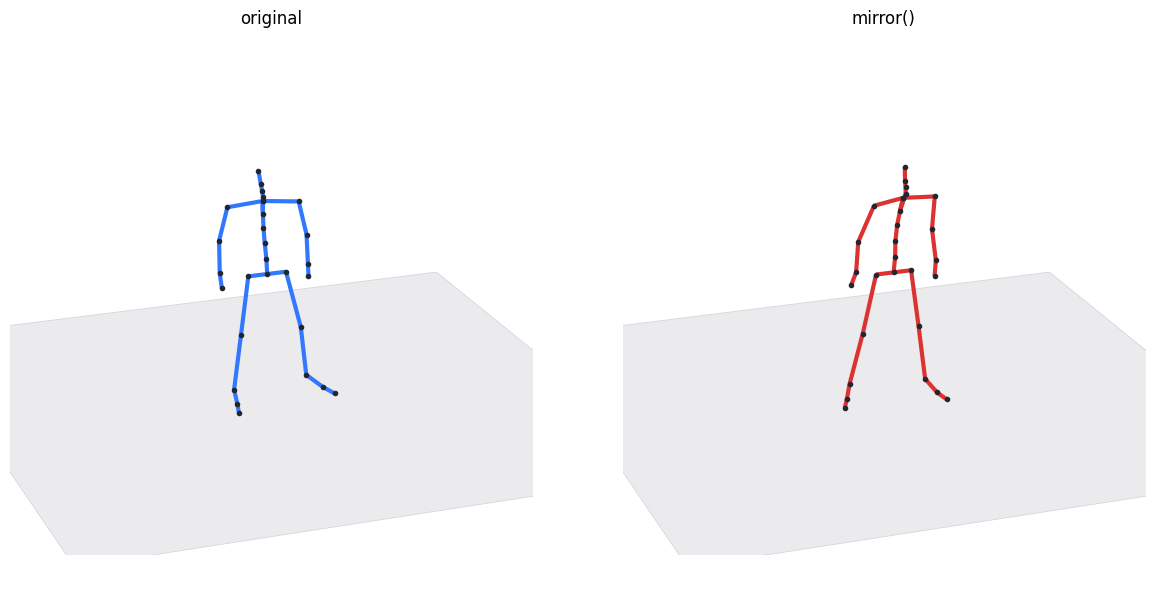

In [16]:
pybvh.bvhplot.frame([bvh, bvh.mirror()], frame=FRAME, labels=["original", "mirror()"]);

**`rotate_vertical`** & **`translate_root`** — yaw the whole motion about the up axis (the one rotation that preserves ground contact), and shift it by a constant offset. The top-down root paths show both at once: the rotated path pivots 90° about the origin, the translated one is the same shape displaced.

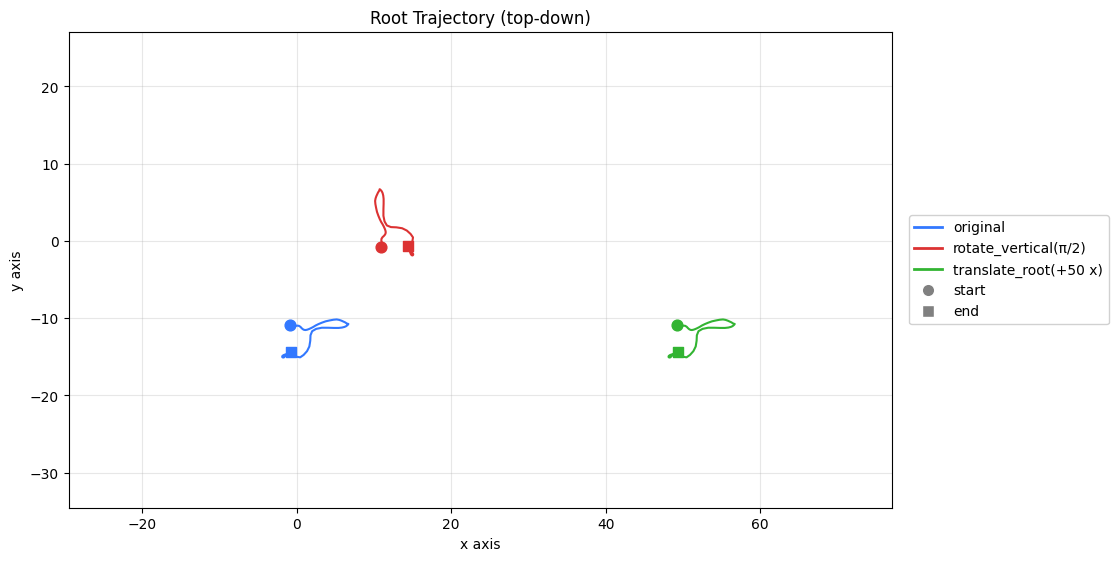

In [17]:
pybvh.bvhplot.trajectory(
    [bvh, bvh.rotate_vertical(np.pi / 2), bvh.translate_root([50, 0, 0])],
    labels=["original", "rotate_vertical(π/2)", "translate_root(+50 x)"]);

**`add_rotation_noise`** — zero-mean Gaussian noise on the joint angles (σ in radians). Calibration on a human skeleton: σ ≈ 0.5° is imperceptible sensor-level noise, ≈ 2° a typical augmentation, ≈ 5° clearly visible, > 10° destructive.

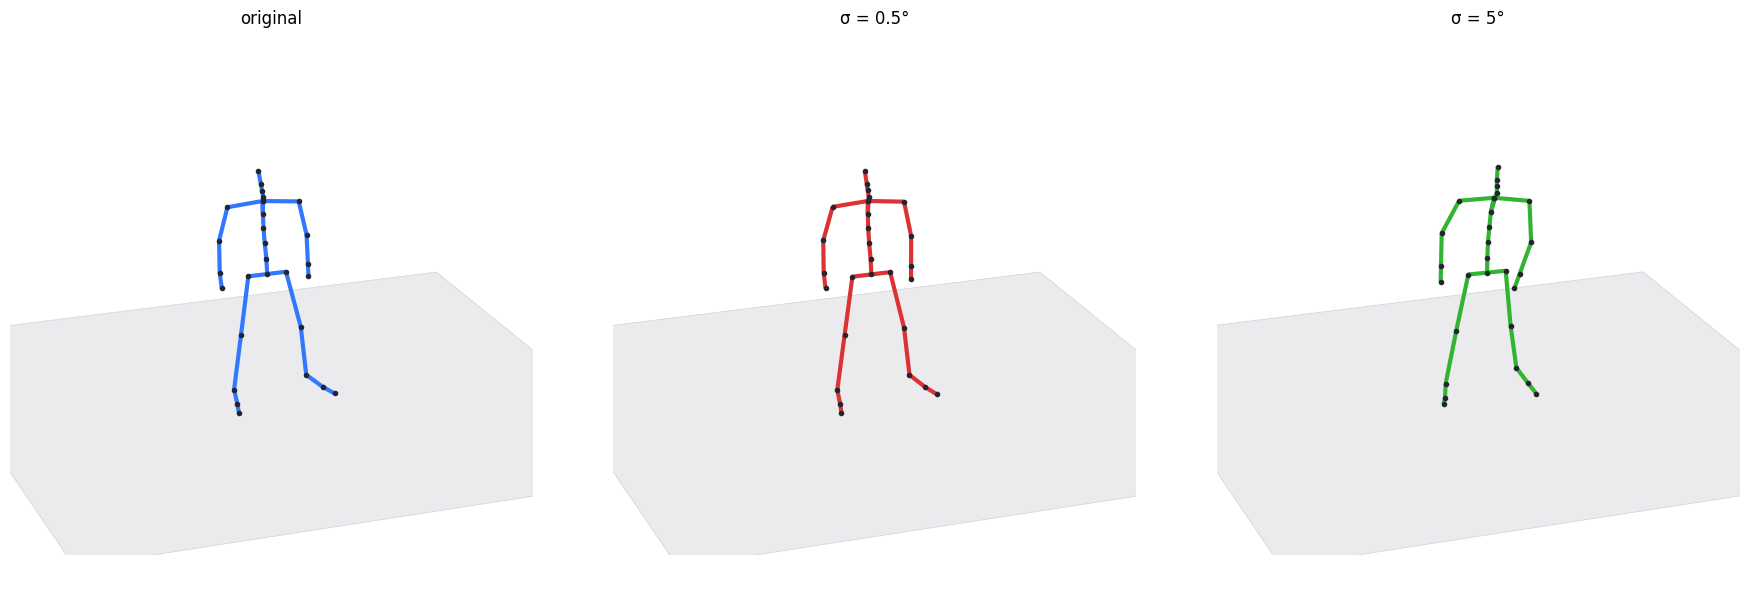

In [18]:
pybvh.bvhplot.frame(
    [bvh,
     bvh.add_rotation_noise(sigma=np.radians(0.5), rng=np.random.default_rng(42)),
     bvh.add_rotation_noise(sigma=np.radians(5.0), rng=np.random.default_rng(42))],
    frame=FRAME, labels=["original", "σ = 0.5°", "σ = 5°"]);

**`perturb_speed`** — changes how fast the motion plays by resampling (SLERP under the hood). The subtlety worth a figure: it changes the **frame count**, not the frame rate — this 75-frame 30 fps clip at factor 2 becomes ~38 frames, still at 30 fps.

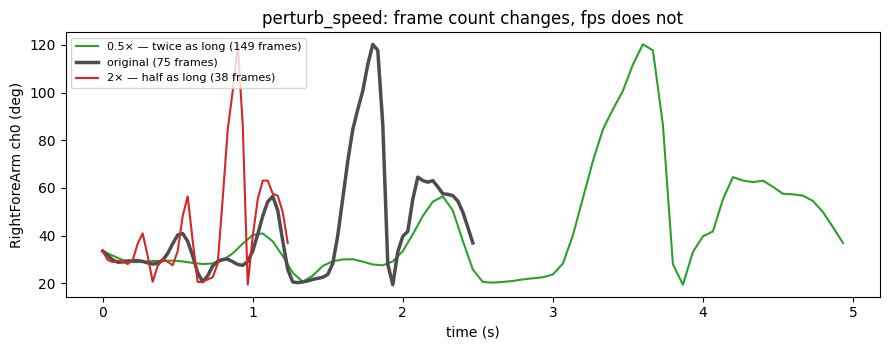

In [19]:
gp.fig_perturb_speed(bvh, bvh.perturb_speed(0.5), bvh.perturb_speed(2.0))

**`drop_frames`** — simulates mocap dropouts: a random fraction of frames is **replaced** (not removed) by values interpolated from the nearest kept neighbours — linear for the root, SLERP for rotations. Same frame count out; the red dots mark the re-synthesized frames, visibly flattened where fine motion was lost.

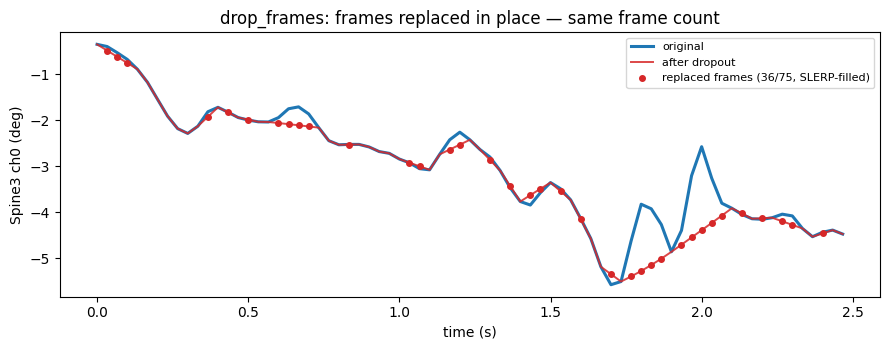

In [20]:
gp.fig_drop_frames(bvh, bvh.drop_frames(drop_rate=0.5, rng=np.random.default_rng(0)))

**Composing transforms** — every transform returns a new `Bvh`, so augmentation pipelines chain:

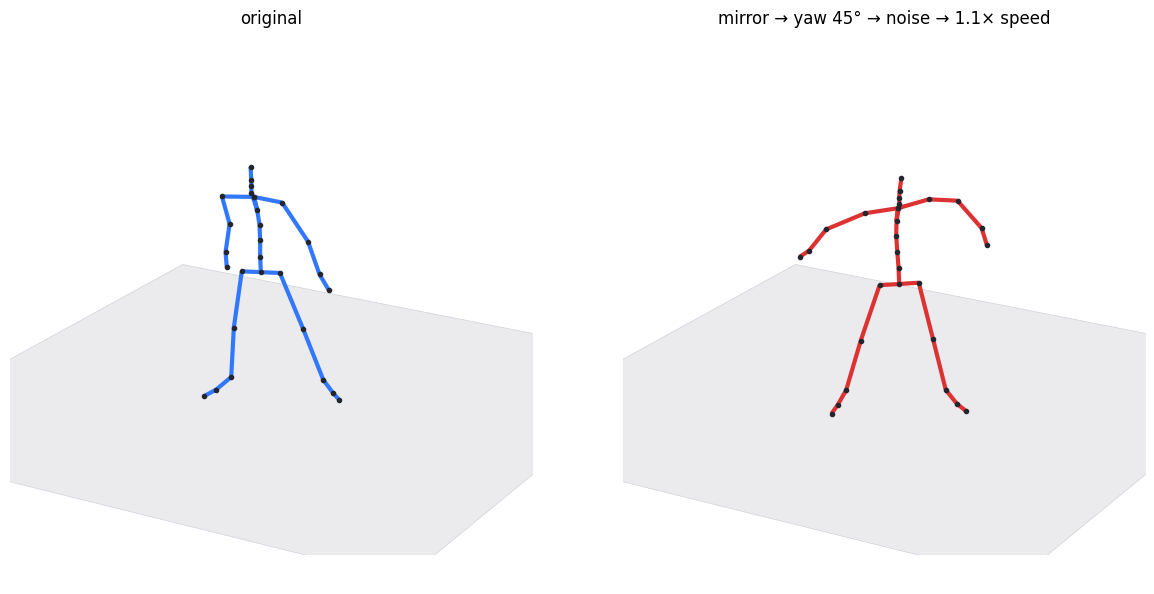

In [21]:
augmented = (bvh.mirror()
                .rotate_vertical(np.pi / 4)
                .add_rotation_noise(sigma=0.02, rng=np.random.default_rng(42))
                .perturb_speed(1.1))
pybvh.bvhplot.frame([bvh, augmented], frame=45,
                    labels=["original", "mirror → yaw 45° → noise → 1.1× speed"],
                    camera=(120, 20));

## 4 · Skeleton & frame ops

Editing the skeleton and the timeline. Full prose: the [Skeleton Operations guide](https://victors-67.github.io/pybvh/guide/skeleton-ops/).

**`scale`**, **`retarget`** & **`extract_joints`** — resize the skeleton (rotations untouched), copy another skeleton's bone proportions while keeping the motion (the dataset-normalization move), and keep a subset of joints (removed joints' offsets collapse into the nearest kept descendant). Left to right on **one shared scale**: original, scaled 0.5×, a 1.5×-tall clip retargeted back to the original proportions (so it matches the original's size again), and an 11-joint subset.

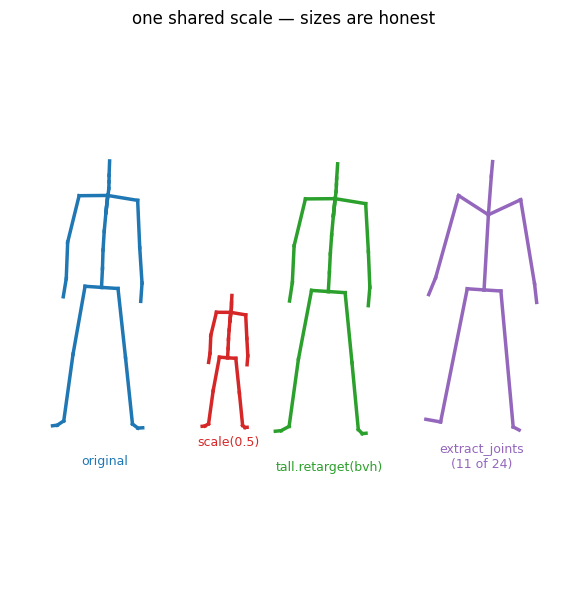

In [22]:
tall = bvh.scale(1.5)
major = ["Hips", "Spine3", "Head", "RightArm", "RightHand", "LeftArm", "LeftHand",
         "RightUpLeg", "RightFoot", "LeftUpLeg", "LeftFoot"]
gp.fig_skeleton_ops(
    [bvh, bvh.scale(0.5), tall.retarget(bvh), bvh.extract_joints(major)],
    ["original", "scale(0.5)", "tall.retarget(bvh)", "extract_joints\n(11 of 24)"], FRAME)

**`resample`** — change the frame rate; the new samples are SLERP-interpolated onto the same motion. (Slicing `bvh[10:50]` and concatenation `bvh_a + bvh_b` round out the timeline operations — no figure needed.)

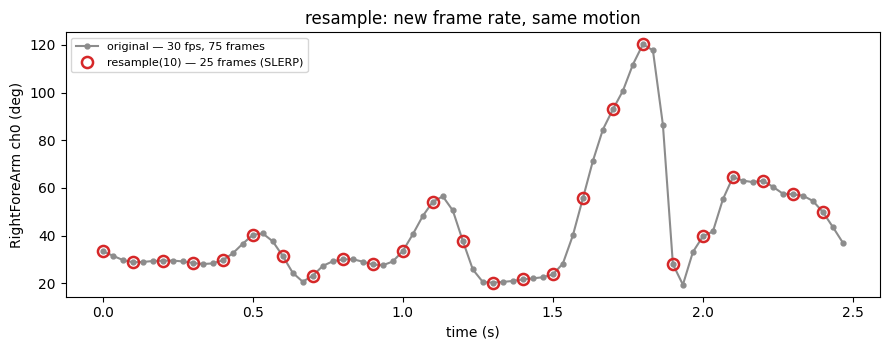

In [23]:
gp.fig_resample(bvh, bvh.resample(10))

## 5 · Contacts & feature export

From motion to ML-ready labels and arrays. Contact detection needs locomotion to be interesting, so this section runs on the **walking clip** loaded in section 1 — first the clip itself, rendered from a fixed side camera so the skeleton walks through world space. The gait descriptors in section 9 reuse it too.

In [24]:
walk_gif = gp.walk_clip_gif(walk)

![the walking clip, rendered by bvh.render with a fixed side camera](https://raw.githubusercontent.com/VictorS-67/pybvh/main/gallery/feature_gallery_walk.gif)

**`foot_contacts`** — binary planted/swing labels per foot per frame. The default detector thresholds two signals and ANDs them (the HuMoR heuristic): foot **speed** (slow enough?) and **clearance** above the estimated floor (low enough?) — each catches the other's failure mode. Here with `adaptive=True` (per-foot thresholds fitted to each foot's own signal — the right setting for known locomotion); the green spans are the detected stance phases.

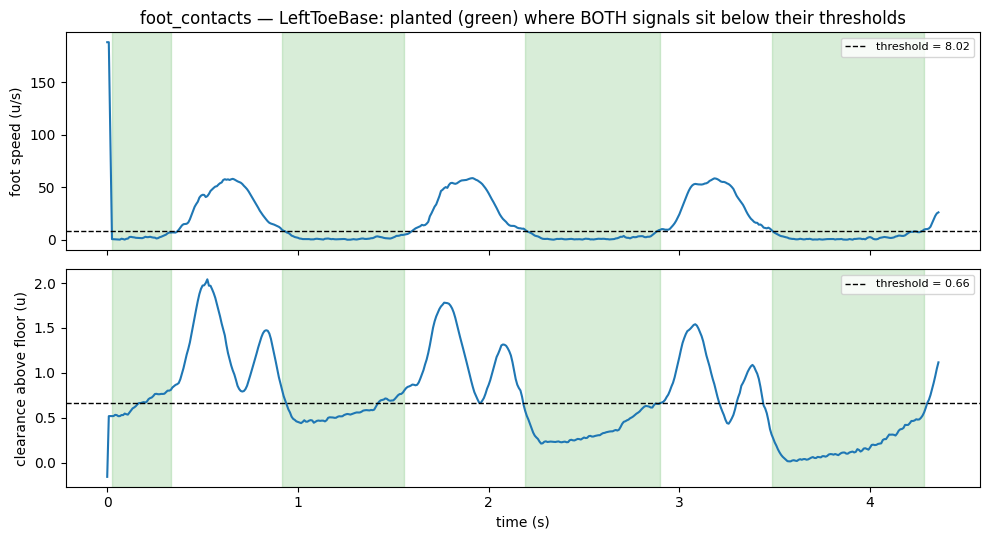

In [25]:
feet = analysis.auto_detect_foot_joints(walk)
gp.fig_foot_contacts_signals(walk, feet)

**`root_trajectory`** — the root's ground-plane position plus its heading as a (sin, cos) pair: the standard root parameterization in motion-generation pipelines. `bvhplot.trajectory(..., facing_arrows=True)` draws the heading along the path.

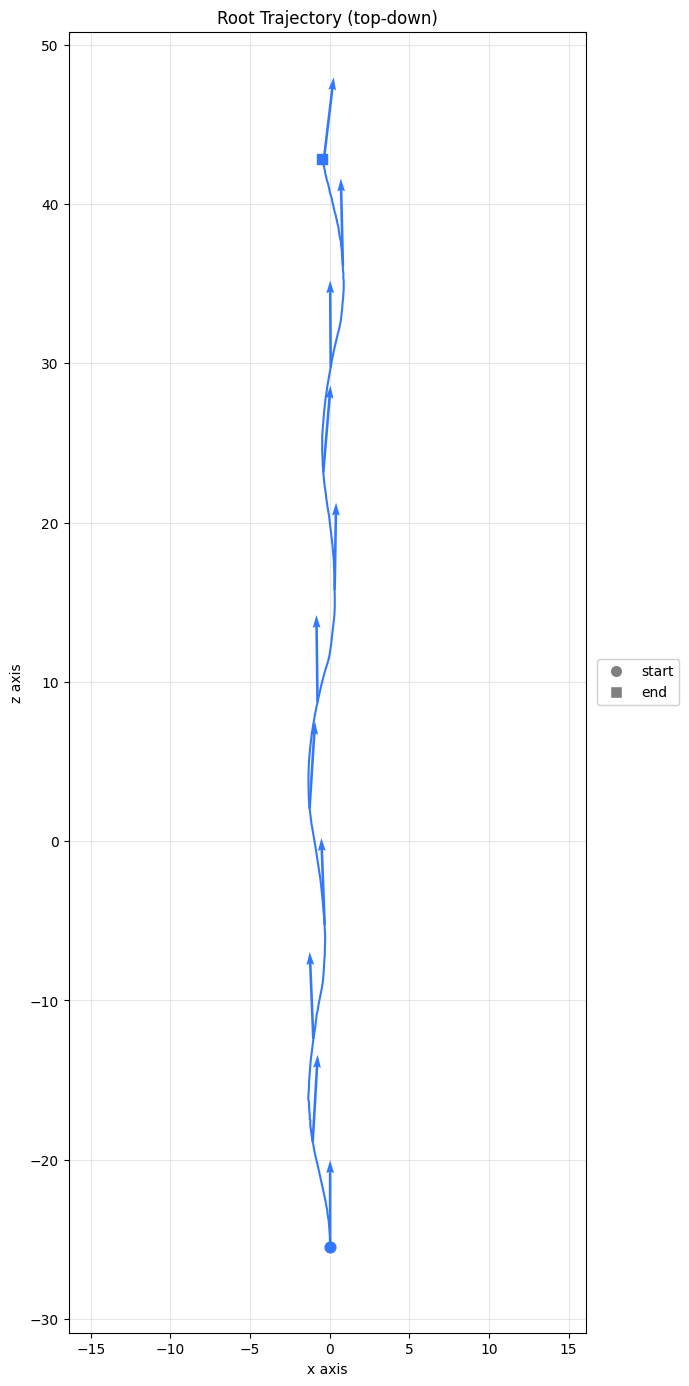

In [26]:
traj_feats = walk.root_trajectory()          # (F, 4): ground a/b + heading sin/cos
pybvh.bvhplot.trajectory(walk, facing_arrows=True);

**`to_feature_array`** — composes root position, joint rotations (any representation), velocities, and foot contacts into one flat `(F, D)` array; **`feature_array_layout`** reports each block's column slice so downstream code never counts columns. The diagram shows the layout of the exact call below.

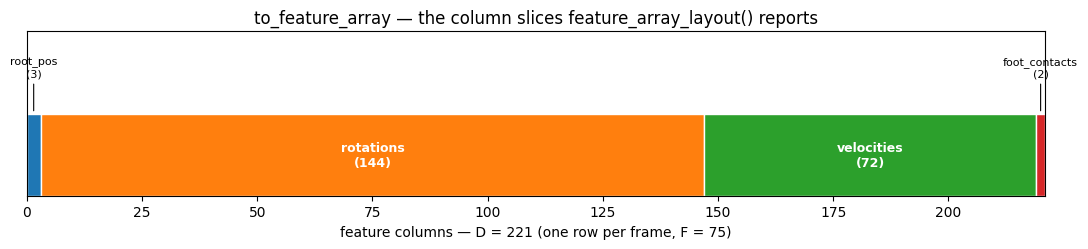

In [27]:
feat = bvh.to_feature_array(representation="6d",
                            include_velocities=True, include_foot_contacts=True)
layout = bvh.feature_array_layout(num_feet=2, representation="6d",
                                  include_velocities=True, include_foot_contacts=True)
gp.fig_feature_layout(layout, feat.shape)

---
Everything below is the quantitative **motion-descriptor layer** added in pybvh 0.8.0 — geometry, dynamics, gait, SE(3), and signal utilities, each drawn so the picture explains the number. Prose overview: the [Motion Descriptors guide](https://victors-67.github.io/pybvh/guide/motion-descriptors/).

## 6 · Geometry — relations between points

These measure relationships among joint *positions*. Each is drawn on a single pose with the measured quantity labelled.

**`inter_joint_distance`** — the straight-line distance between two joints. The dashed line is the measured segment; its length is printed on it.

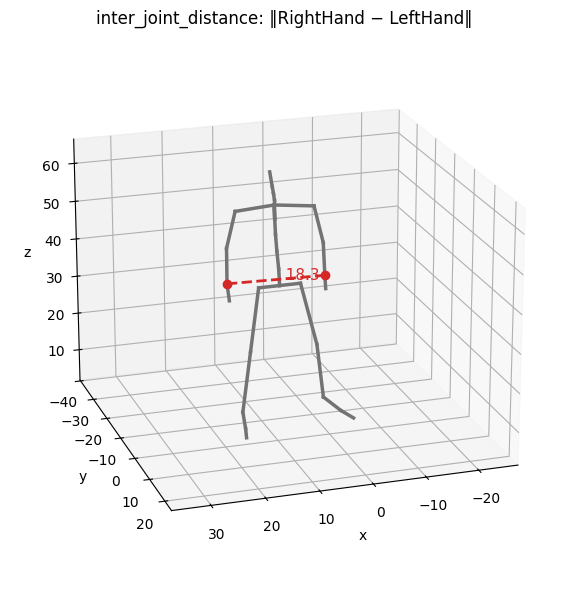

In [28]:
d = bvh.inter_joint_distance([("RightHand", "LeftHand")])[FRAME, 0]
gp.fig_inter_joint_distance(bvh, FRAME, "RightHand", "LeftHand", d,
                            "inter_joint_distance: ‖RightHand − LeftHand‖")

**`joint_angle`** — the angle at a *vertex* joint between its two neighbours. The two red bones meet at the elbow; the orange arc and label show the angle. (Drawn at the most-bent-elbow frame so the angle is unmistakable.)

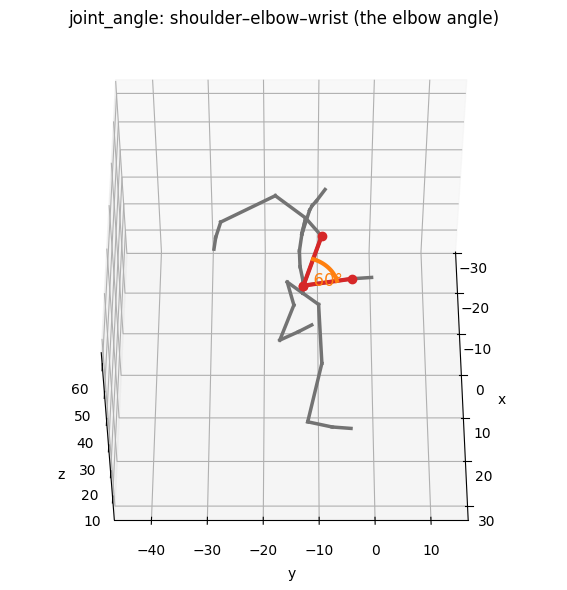

In [29]:
elbow = bvh.joint_angle("RightArm", "RightForeArm", "RightHand", degrees=True)
fa = int(np.argmin(elbow))                  # most-bent elbow frame
gp.fig_joint_angle(bvh, fa, "RightArm", "RightForeArm", "RightHand", elbow[fa],
                   "joint_angle: shoulder–elbow–wrist (the elbow angle)")

**`segment_axis_angle`** — the angle of a bone relative to a reference axis (here the world up). The blue arrow is "up", the red bone is the segment, the arc is the angle between them.

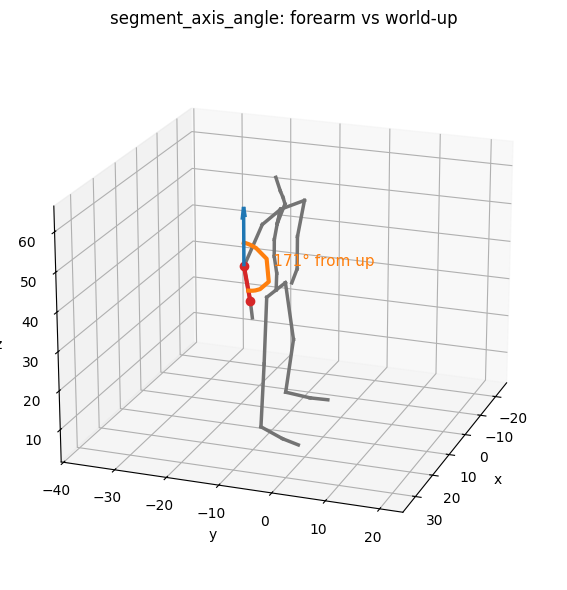

In [30]:
saa = bvh.segment_axis_angle("RightForeArm", "RightHand", degrees=True)[FRAME]
gp.fig_segment_axis_angle(bvh, FRAME, "RightForeArm", "RightHand", saa,
                          "segment_axis_angle: forearm vs world-up")

**`triangle_area`** — the area of the triangle spanned by three joints (a coarse "openness" measure). The shaded triangle is the measured region.

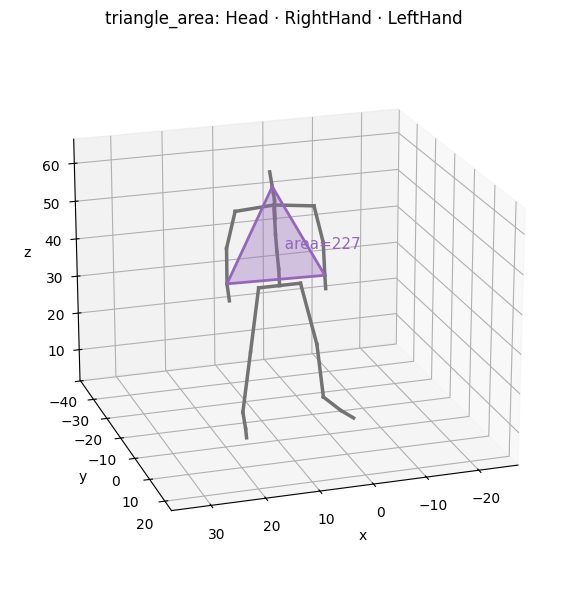

In [31]:
area = bvh.triangle_area("Head", "RightHand", "LeftHand")[FRAME]
gp.fig_triangle_area(bvh, FRAME, "Head", "RightHand", "LeftHand", area,
                     "triangle_area: Head · RightHand · LeftHand")

**`point_to_plane_distance`** & **`point_to_segment_distance`** — signed distance from a point to an infinite plane, and shortest distance to a finite segment (clamped to the endpoints). Shown on a clean synthetic setup so the perpendicular drop is unmistakable.

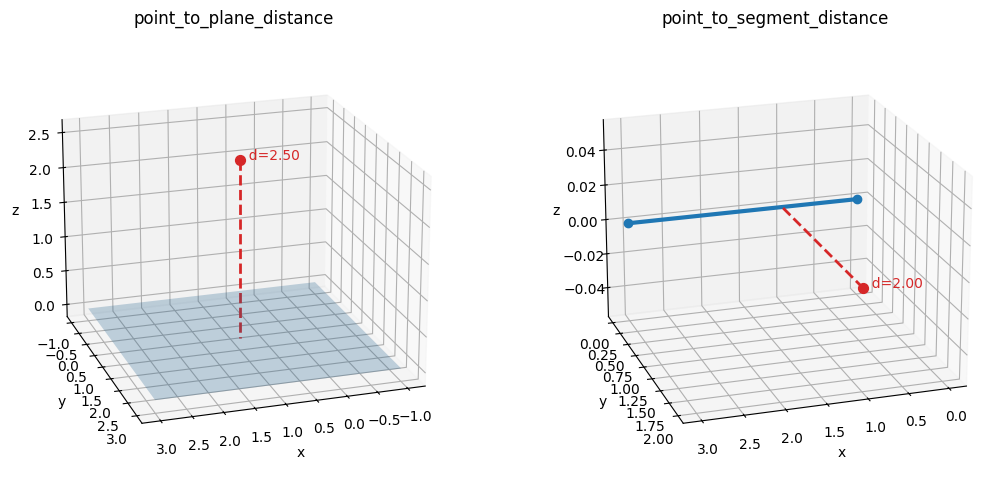

In [32]:
gp.fig_point_to_plane_segment_synthetic()   # didactic illustration on synthetic points (no bvh feature)

**On the skeleton.** The same two distances become useful motion features: `point_to_plane_distance` to the ground gives a foot's **clearance** (how high it is lifted off the floor), and `point_to_segment_distance` to a body axis gives how far a hand **reaches** from the torso. Both are drawn on the same pose (the frame where the toe is most lifted), with the red perpendicular as the measured distance.

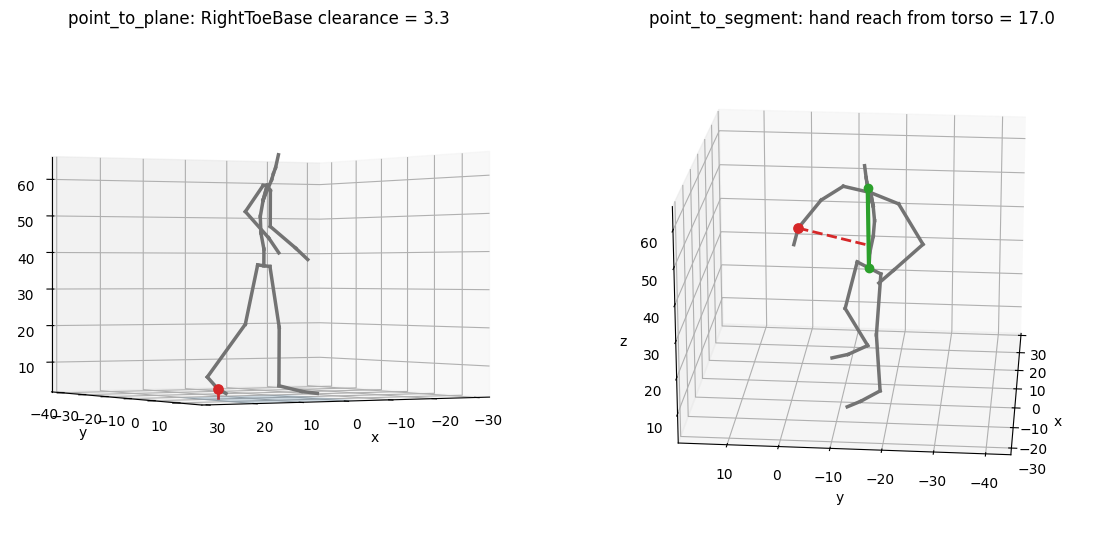

In [33]:
floor = pos[:, :, 2].min()
kf = int(np.argmax(pos[:, idx("RightToeBase"), 2]))          # most-lifted-toe frame
clearance = geometry.point_to_plane_distance(pos[kf, idx("RightToeBase")],
                                             np.array([0, 0, floor]), gp.UP)
reach = geometry.point_to_segment_distance(pos[kf, idx("RightHand")],
                                           pos[kf, idx("Hips")], pos[kf, idx("Neck")])
gp.fig_point_to_plane_segment_skeleton(bvh, kf, clearance, reach)

## 7 · Geometry — bounding volumes & centre of mass

Whole-pose descriptors, drawn as the actual bounding shape around the skeleton.

**`bounding_box`** (axis-aligned), **`bounding_sphere`** (Ritter, approximate), **`bounding_ellipsoid`** (PCA-aligned) — three ways to enclose the pose. Each wireframe encloses every joint; the ellipsoid tilts with the body's spread.

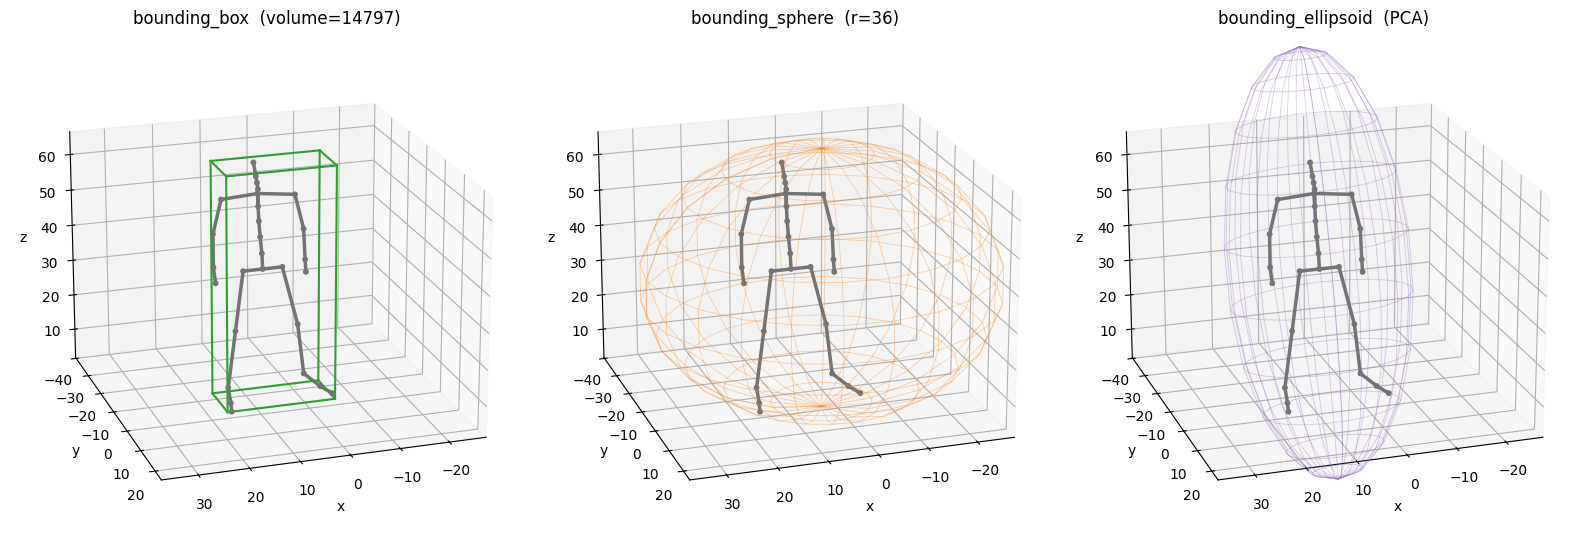

In [34]:
box, sph = bvh.bounding_box(), bvh.bounding_sphere()
ell = geometry.bounding_ellipsoid(P)
gp.fig_bounding_volumes(bvh, FRAME, box, sph, ell)

**`center_of_mass`** (uniform centroid) and **`com_displacement`** — the black dot is the per-frame CoM; the dashed line shows how far it has travelled from the **start** CoM (frame 0, the default reference). The CoM *trail* over the whole clip is faint blue.

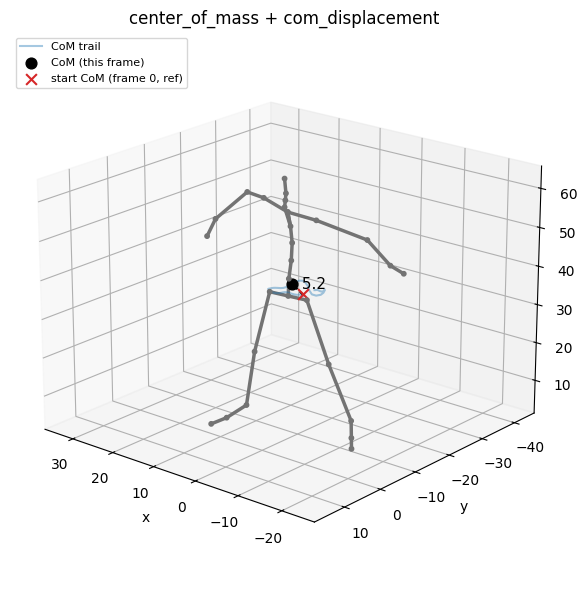

In [35]:
com = bvh.center_of_mass()
disp = bvh.com_displacement()
gp.fig_com(bvh, com, disp, frame=50)

**`verticality`** — vertical extent ÷ horizontal extent. The green bar is the height span (along up); the orange bar is the horizontal width. Their ratio is the verticality (> 1 = tall/upright).

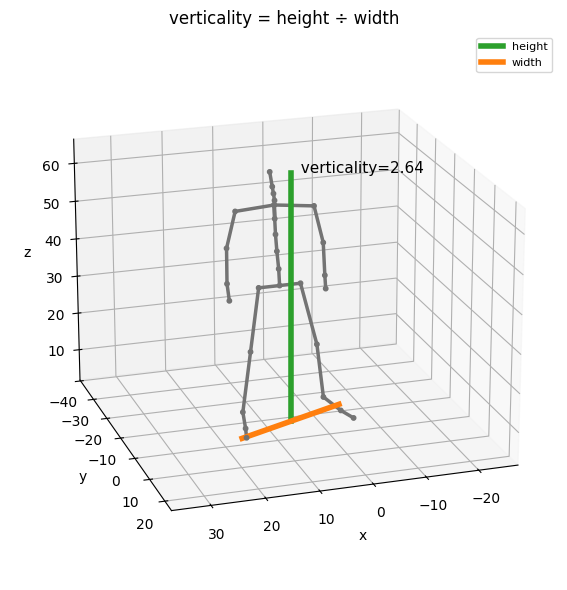

In [36]:
gp.fig_verticality(bvh, FRAME, bvh.verticality()[FRAME])

## 8 · Geometry — trajectory descriptors

These read a *single joint's path* over the whole clip. We use the right hand.

In [37]:
JT = "RightHand"
traj = pos[:, idx(JT), :]

First, to make the static trajectory plots below intuitive, watch the hand **trace its path**: the skeleton animates while the blue trail grows behind the hand, frame by frame. The finished blue curve is the hand trajectory every descriptor in this section reads as `traj` (the GIF is resampled to 20 fps so it plays in real time).

In [38]:
gif_path = gp.trajectory_trace_gif(bvh, JT)

![the right hand tracing its trajectory, frame by frame](https://raw.githubusercontent.com/VictorS-67/pybvh/main/gallery/feature_gallery_hand_traj.gif)

**`path_length`** vs **`directness`** — the blue curve is the actual path (its arc length = `path_length`); the dashed chord is the straight start→end distance. `directness` = chord ÷ path (1 = perfectly straight).

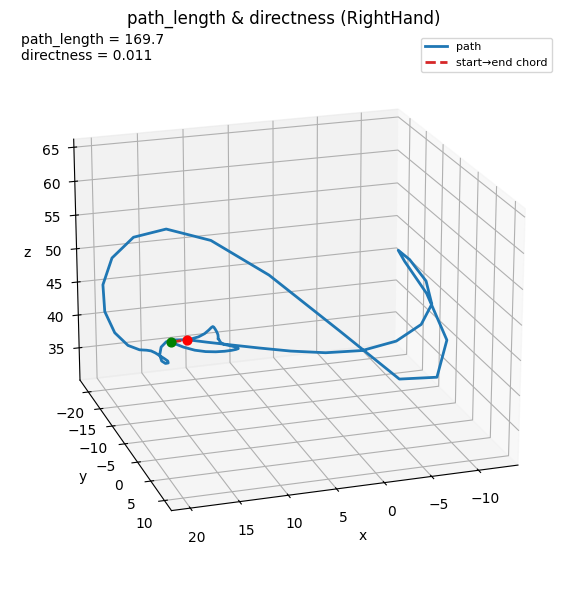

In [39]:
gp.fig_path_directness(traj, bvh.path_length(JT), bvh.directness(JT),
                       f"path_length & directness ({JT})")

**`curvature`** — how sharply the path bends (κ = 1 ÷ the radius of the circle that best hugs the path at each point). Drawn by colouring the trajectory: bright = tight turn, dark = nearly straight.

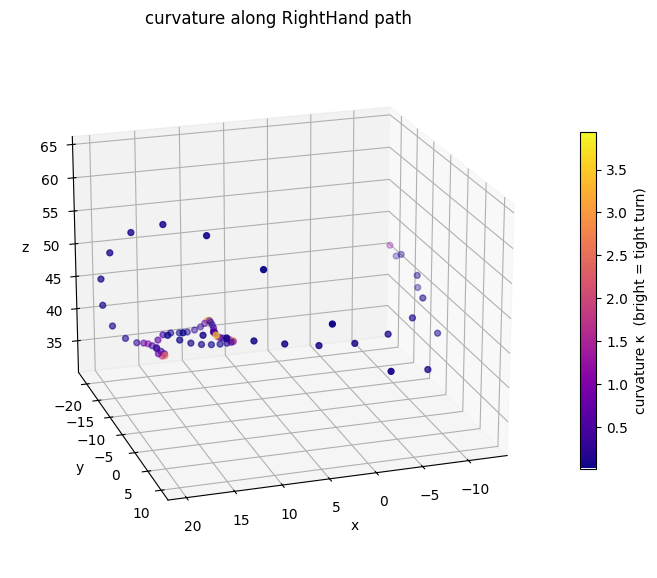

In [40]:
kappa = bvh.curvature(JT)
gp.fig_curvature(traj, kappa, f"curvature along {JT} path")

**`torsion`** — how a path twists *out of its plane* (0 for any flat curve). It is a *third*-derivative quantity, so on real mocap it is swamped by finite-difference noise and spikes wherever the path is momentarily straight (its denominator → 0). To see what it actually measures we use a clean synthetic curve — a flat circle that lifts into a helix: torsion is ~0 on the flat part and rises where the curve leaves the plane.

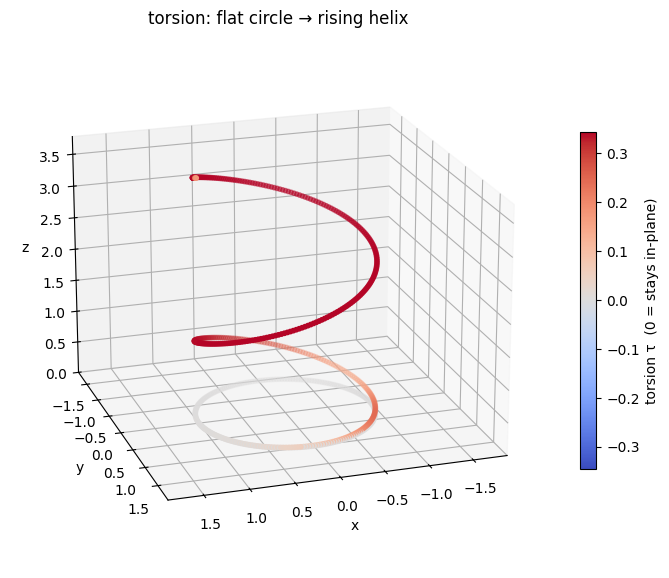

In [41]:
s = np.linspace(0, 6 * np.pi, 600)
climb_rate = 0.4 * (1 + np.tanh(s - 3 * np.pi)) / 2          # vertical speed: smoothly 0 → 0.4
z = np.cumsum(climb_rate) * (s[1] - s[0])                    # integrate it: flat, then climbs
helix = np.stack([np.cos(s), np.sin(s), z], axis=1)          # smooth join → no torsion spike
tor = geometry.torsion(helix, s[1] - s[0])
gp.fig_torsion(helix, tor, "torsion: flat circle → rising helix")

> **Note — the ratio torsion / curvature - or τ/κ (Lancret invariant).** Curvature and torsion are the *complete* pair of Frenet invariants: together they fix a 3D curve up to a rigid motion. Their ratio has a clean meaning — **τ/κ is constant iff the curve is a generalized helix**, and that constant *is* the helix's pitch. On the curve above it is ~0 along the flat circle and ≈0.40 (the climb rate) on the helix. It's a one-liner from the two primitives — `geometry.torsion(traj, dt) / geometry.curvature(traj, dt)` — and is left at that: as a feature it inherits torsion's noise *and* adds a second blow-up where κ→0, so it stays a documented composition rather than a library call.

**`movement_phase`** — speed·curvature, so it peaks where the joint moves both *fast* and *sharply*. Shown along the real hand path: bright marks the moments that combine high speed with a tight turn.

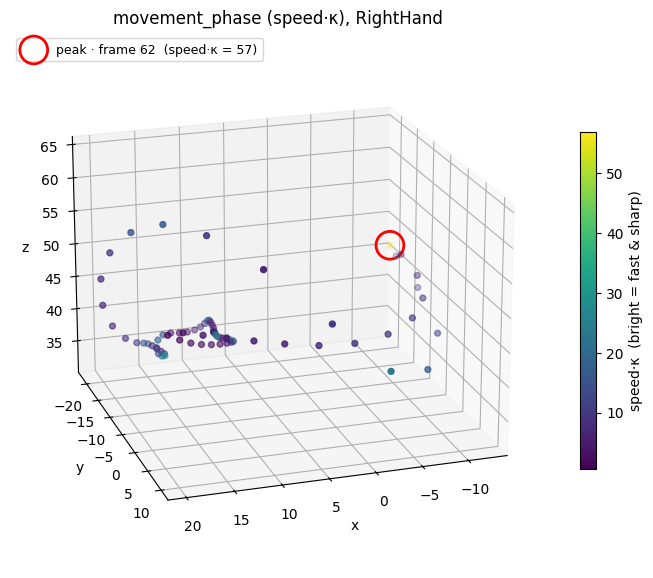

In [42]:
mp = geometry.movement_phase(traj, dt)
gp.fig_movement_phase(bvh, JT, mp)

**`ground_path`** — the joint's path projected onto the ground plane (its shadow). `distance` is the length of that shadow; `area` is the region it encloses (shoelace). The 3D path, its shadow, and the filled area are shown.

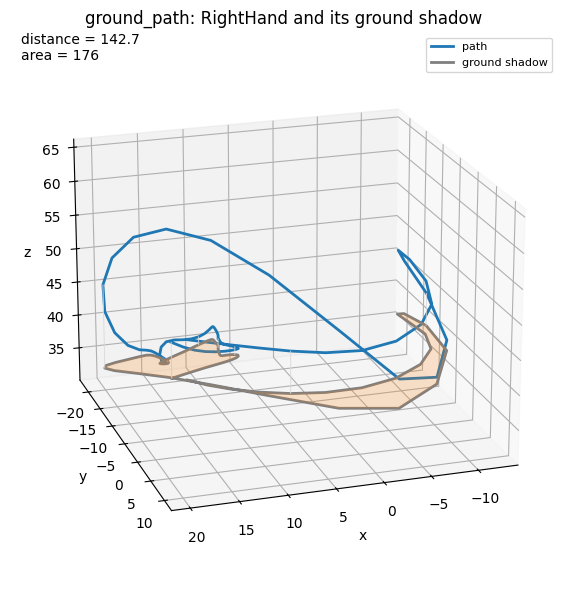

In [43]:
gp.fig_ground_path(bvh, JT, bvh.ground_path(JT))

**`pose_distance`** — the Euclidean distance between two whole poses. Computed between *every* pair of frames it gives a self-similarity matrix: with this colormap bright = similar (the diagonal is brightest — every pose matches itself) and dark = dissimilar. Recurring motifs show up as off-diagonal bright streaks.

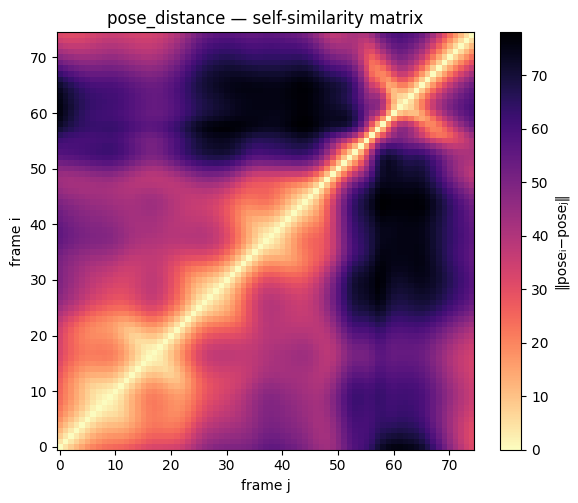

In [44]:
D = geometry.pose_distance(pos[:, None], pos[None, :])      # (F, F) self-similarity
gp.fig_pose_distance(D)

**`mean_pose_subtract`** — removes the average pose, returning a per-frame, per-joint deviation from it (shape `(F, N, 3)`) — the motion *about* the mean. The figure shows the mean pose (grey skeleton, what gets subtracted) and a single frame's slice of that deviation field (red arrows).

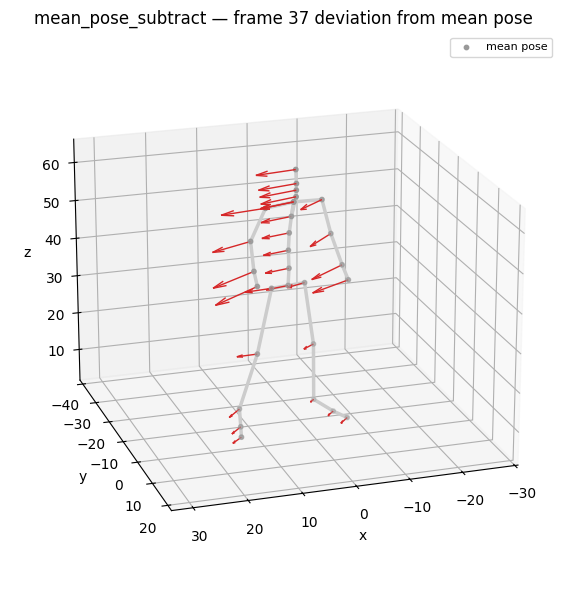

In [45]:
resid = geometry.mean_pose_subtract(pos)                    # motion about the mean pose
gp.fig_mean_pose_subtract(bvh, FRAME, resid)

## 9 · Analysis — dynamics

Velocity-derived descriptors. Most are best read on the signal itself, with the quantity they compute annotated directly. The right-hand speed profile and sampling rate are reused below.

The traced right-hand clip from section 8 once more — it is the signal these descriptors summarize:

![the right hand tracing its trajectory, frame by frame](https://raw.githubusercontent.com/VictorS-67/pybvh/main/gallery/feature_gallery_hand_traj.gif)

In [46]:
speed = np.linalg.norm(bvh.node_velocities()[:, idx(JT)], axis=-1)
fs = 1.0 / dt

**`node_jerk` / `joint_jerk`** — the third derivative of position (rate of change of acceleration). Large jerk = abrupt, unsmooth motion. Shown as the hand's speed, acceleration, and jerk magnitude stacked by frame. Note that the acceleration here is the full acceleration-vector magnitude, so it also spikes on sharp turns (direction changes), not only on speed changes.

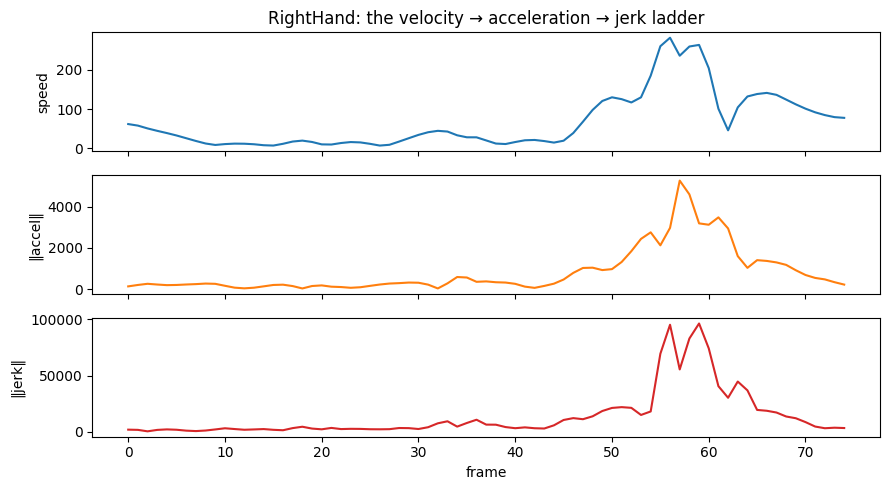

In [47]:
acc = np.linalg.norm(bvh.node_accelerations()[:, idx(JT)], axis=-1)
jerk = np.linalg.norm(bvh.node_jerk()[:, idx(JT)], axis=-1)
gp.fig_jerk_ladder(np.arange(F), speed, acc, jerk, f"{JT}: the velocity → acceleration → jerk ladder")

**`smoothness(metric=…)`** scores a *speed profile*; each metric has its own scale and direction (the next cell spells them out). **SPARC** — more negative = less smooth — is the one with a clean geometric picture, so we use it to build intuition here; the others have no natural 2D drawing and are compared as numbers below. *(Synthetic on purpose: smoothness is a contrast metric, so we show a known smooth vs jerky pair.)* **Left:** the two speed profiles (the jerky one's wiggle count is what `number_of_peaks` reports). **Right:** their normalized spectra. SPARC is the *arc length* of this curve: the smooth motion's energy sits entirely at low frequency (a short arc), while the jerky tremor adds a bump at 7 Hz that lengthens the arc — that extra length is its lower SPARC.

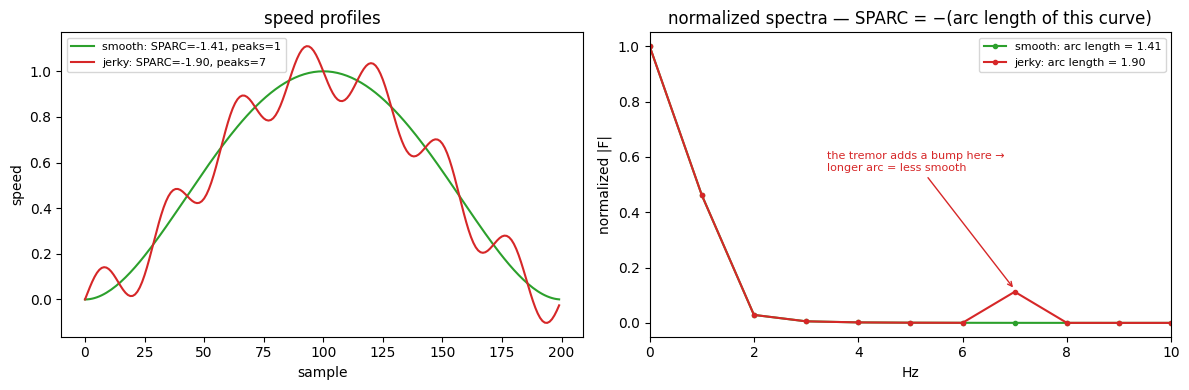

In [48]:
# -- synthetic data creation --
FS = 200.0                                           # sampling rate of the synthetic signal
tt = np.arange(200) / FS                             # one second of samples at FS
smooth = (tt ** 2 * (1 - tt) ** 2)
smooth /= smooth.max()
jerky = smooth + 0.12 * np.sin(2 * np.pi * 7 * tt)   # a superimposed 7 Hz tremor adds jerk
# -- data analysis --
sparc = [analysis.smoothness(p, FS, metric="sparc") for p in (smooth, jerky)]
gp.fig_smoothness_profiles(smooth, jerky, sparc, FS)

**The full `smoothness` family** — every metric scored on the same smooth vs jerky pair through the `smoothness(metric=…)` dispatcher (the call is now shown in the cell). The jerk-based metrics all rate the tremulous motion as less smooth (more negative for SPARC / DLJ / LDLJ, larger for the squared-jerk metrics and the peak count); `speed_metric` captures a different notion (mean-to-peak ratio), so it need not move the same way.

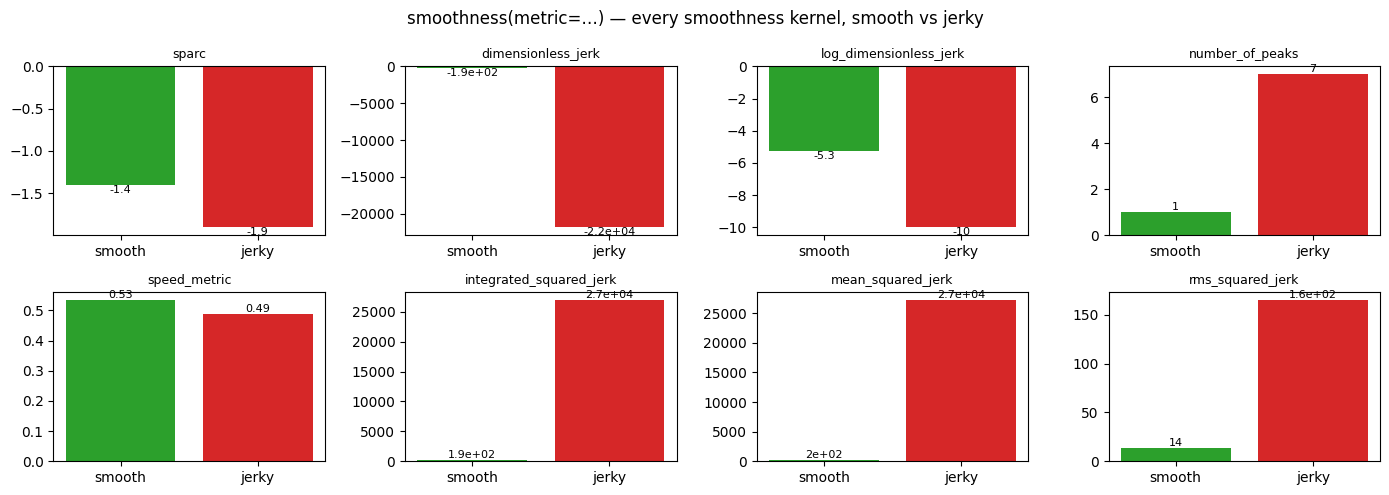

In [49]:
metrics = ["sparc", "dimensionless_jerk", "log_dimensionless_jerk", "number_of_peaks",
           "speed_metric", "integrated_squared_jerk", "mean_squared_jerk", "rms_squared_jerk"]
scores = {m: [analysis.smoothness(p, FS, metric=m) for p in (smooth, jerky)] for m in metrics}
gp.fig_smoothness_bars(scores)

**`velocity_reductions`** — scalar summaries of a speed profile: `peak`, `mean`, their ratio `peak_to_mean`, `peak_acceleration` (the steepest speed-up) and `peak_deceleration` (the steepest slowing). All shown on the hand's speed.

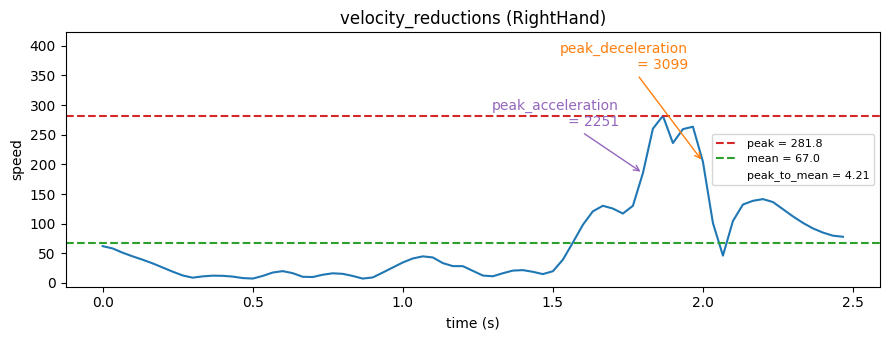

In [50]:
vr = analysis.velocity_reductions(speed, fs=fs)
gp.fig_velocity_reductions(t, speed, vr, fs, f"velocity_reductions ({JT})")

**`zero_crossings`** & **`active_segments` / `active_duration`** — left: where a (centred) signal changes sign, with the count; right: a speed profile with a threshold, the *active* (moving) spans shaded and their total duration.

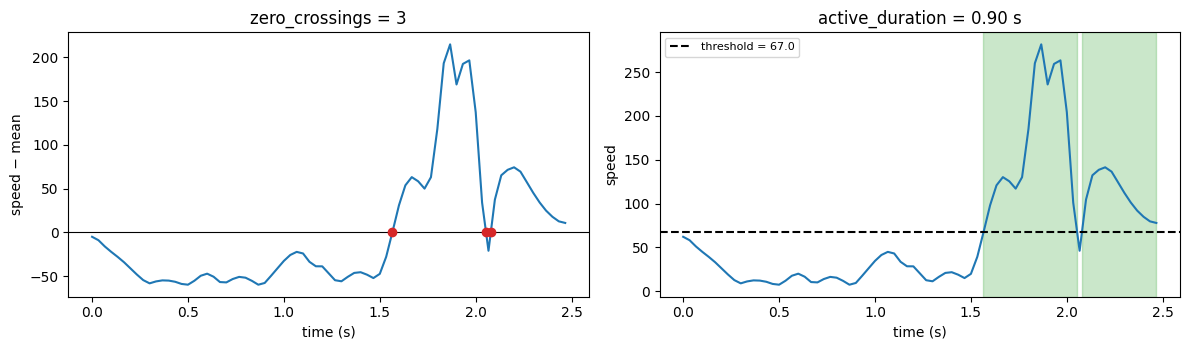

In [51]:
zc = analysis.zero_crossings(speed - speed.mean())
active = analysis.active_duration(speed, speed.mean(), fs)
gp.fig_zero_crossings_active(t, speed, zc, active)

**`kinetic_energy`** — per-frame Σ‖vⱼ‖² over all joints (unit-mass). Left: the energy curve; right: a pose with each joint coloured by its instantaneous speed (red or black = fast), showing *where* the energy is. Pass `masses={joint: m}` for mass-weighted energy — pybvh ships no mass model.

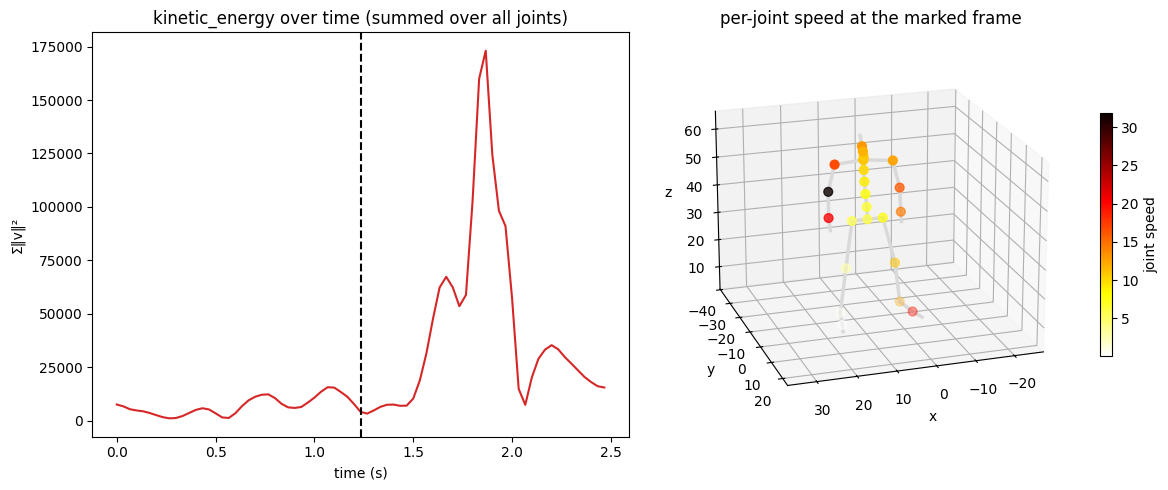

In [52]:
ke = bvh.kinetic_energy()
gp.fig_kinetic_energy(bvh, ke, FRAME, t)

**`range_of_motion`** — the peak-to-peak span of a joint's Euler angles over the clip. Shown as each rotation channel's trace with its min–max band shaded; the band height is the ROM.

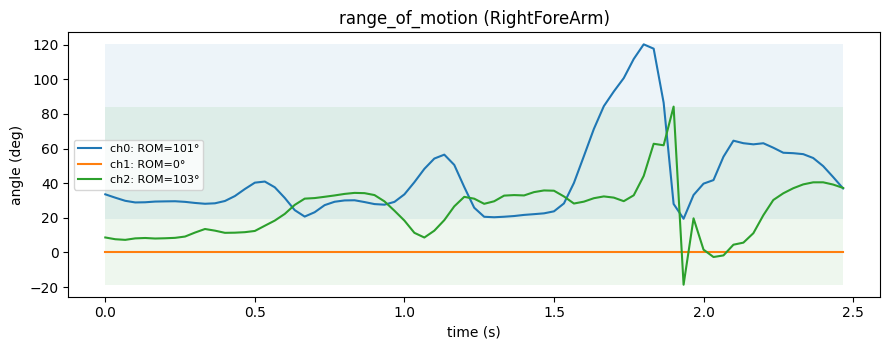

In [53]:
rom = bvh.range_of_motion("RightForeArm")
gp.fig_range_of_motion(bvh, "RightForeArm", rom, t)

Note that ch1 has no range of motion here (ROM = 0°). This is because the forearm's rotation order is `ZYX`, so ch1 is the Y-rotation — and for the elbow that is the **non-hinge** axis: the elbow is a hinge, it flexes in a single plane (captured here by ch0, the Z-rotation, ~101°) and the bone twists along its length (ch2, the X-rotation, ~103° of pronation/supination), but it physically cannot bend sideways, so that channel stays at 0 for the whole clip.

**`cov3dj`** & **`lagged_covariance`** — fixed-size statistical descriptors of a whole sequence: the covariance of all 3D joint coordinates (`cov3dj`, 3N×3N), and the channel covariance at a temporal lag (`lagged_covariance`). Drawn as heatmaps — block structure reflects coordinated joints.

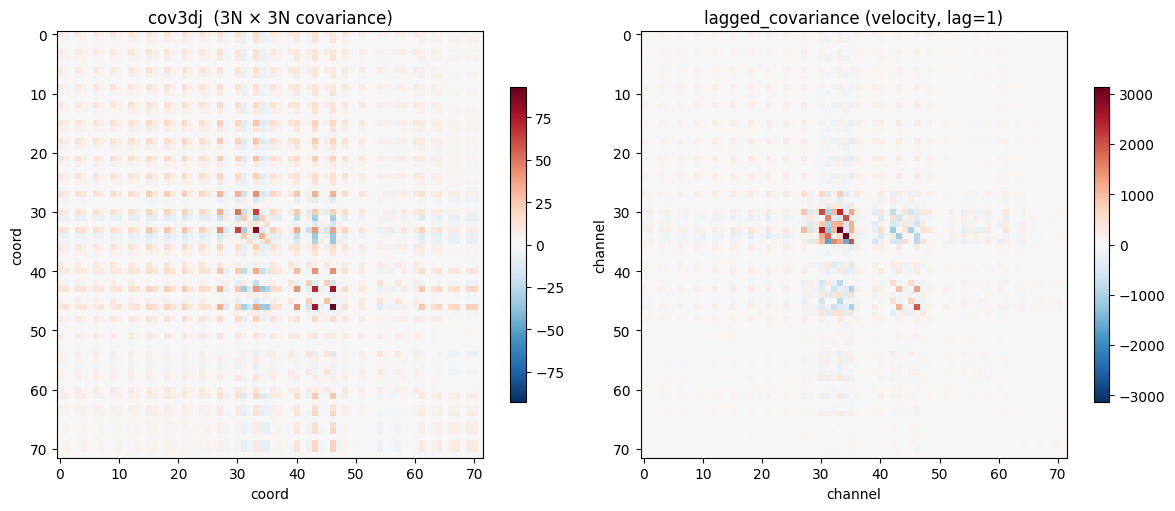

In [54]:
C = analysis.cov3dj(bvh.joint_positions())
L = analysis.lagged_covariance(bvh.joint_velocities().reshape(F, -1), lag=1)
gp.fig_covariance(C, L)

**`skeleton_size`** — the absolute scale proxy: the mean rest-pose distance from the root to the feet (red lines). It scales linearly with the whole skeleton.

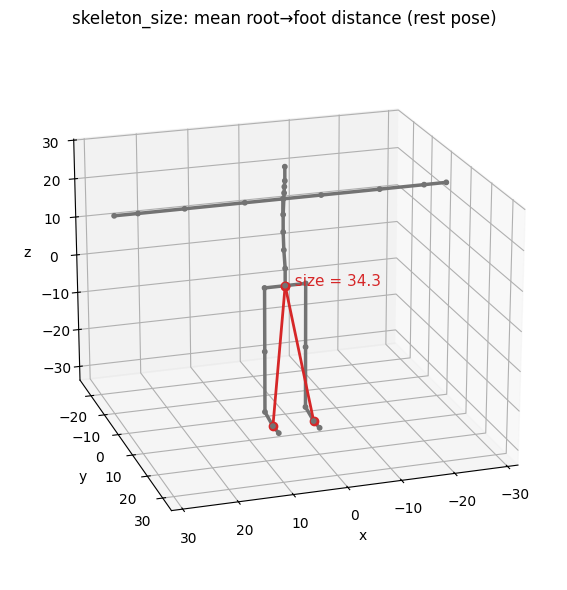

In [55]:
bvh_feet = analysis.auto_detect_foot_joints(bvh)
gp.fig_skeleton_size(bvh, bvh_feet, analysis.skeleton_size(bvh, foot_joints=bvh_feet))

### Gait — on real walking mocap

The remaining descriptors in this section are gait metrics; unlike everything above they run on the **real walking clip** shown in section 5 (`walk`, with its auto-detected `feet`), because gait only becomes meaningful over several real strides.

**`gait_parameters`** — one-pass spatiotemporal gait analysis from foot contacts + foot landings (it also exposes the `cadence` / `stride_length` / `walking_pace` scalars individually). Since gait input is locomotion by definition, it detects contacts with `foot_contacts(…, adaptive=True)` — per-foot thresholds fitted to each foot's own signal, which is what handles retargeted mocap whose feet hover above the estimated floor. **Top:** the contact raster (blue = planted) with double-support frames shaded orange — illustrating `stance_fraction` and `double_support_fraction`. **Bottom:** each foot's ground path (in travel-aligned coordinates) with its landing points marked and joined, so `stride_length` (landing→landing) and left/right `asymmetry` are visible; the remaining scalars are printed in the titles. *(Kinematic only — dynamic gait like joint torques or ground-reaction force needs a physical model and is out of scope.)*

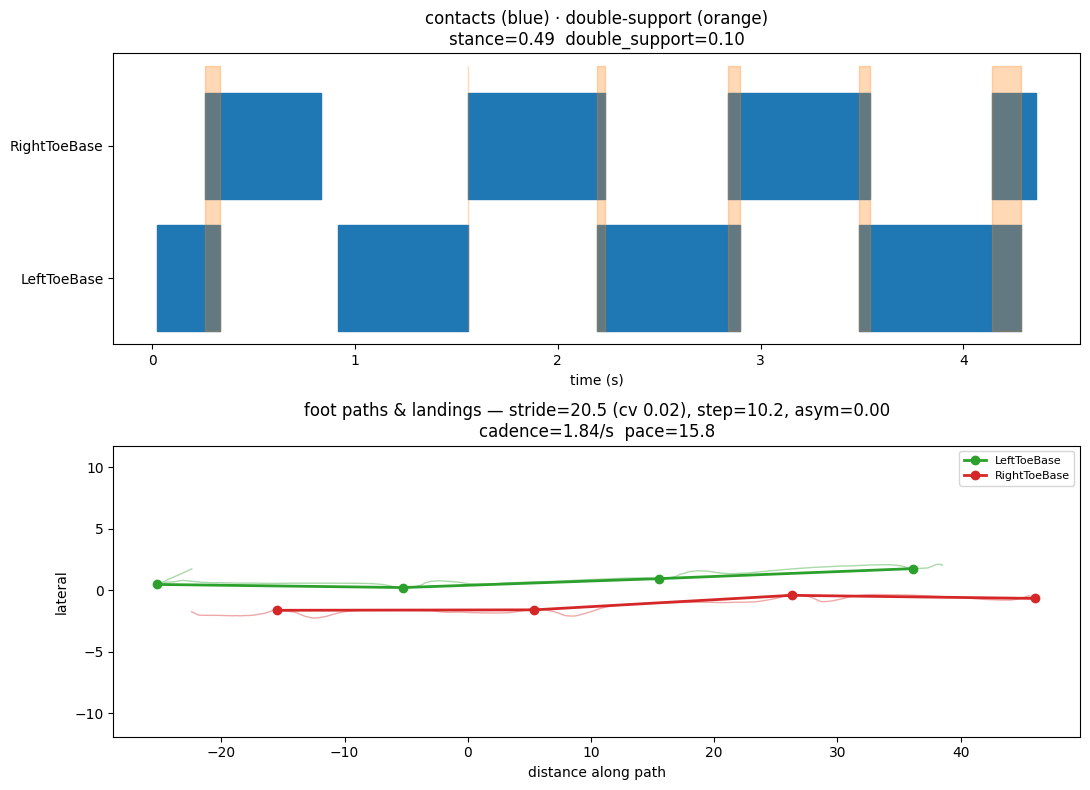

In [56]:
t_walk = np.arange(walk.frame_count) * walk.frame_time
g = walk.gait_parameters(foot_joints=feet)     # feet auto-detected in section 5
gp.fig_gait(walk, feet, g, t_walk)

## 10 · Rotations — SE(3) rigid-transform math

Rigid transforms are drawn as coordinate frames (triads): red/green/blue = the x/y/z axes of the frame.

**`se3_exp` / `se3_log`** — a twist `[ω, v]` (six numbers, rotation first) exponentiates to a 4×4 rigid transform; `se3_log` inverts it exactly (see the inset round-trip). `ω` is an axis-angle vector — here 1.4 rad ≈ 80° about z — and `v` is the twist's *linear generator*, **not** the final translation: the exp map couples it to the ongoing rotation (`d = V(ω)·v`), so the origin of the identity frame (faint) travels along the dashed helix to the black dot at `d ≈ [0.70, 0.59, 0.60]`, where the transformed frame (bold) lands. The grey line is the **true screw axis**.

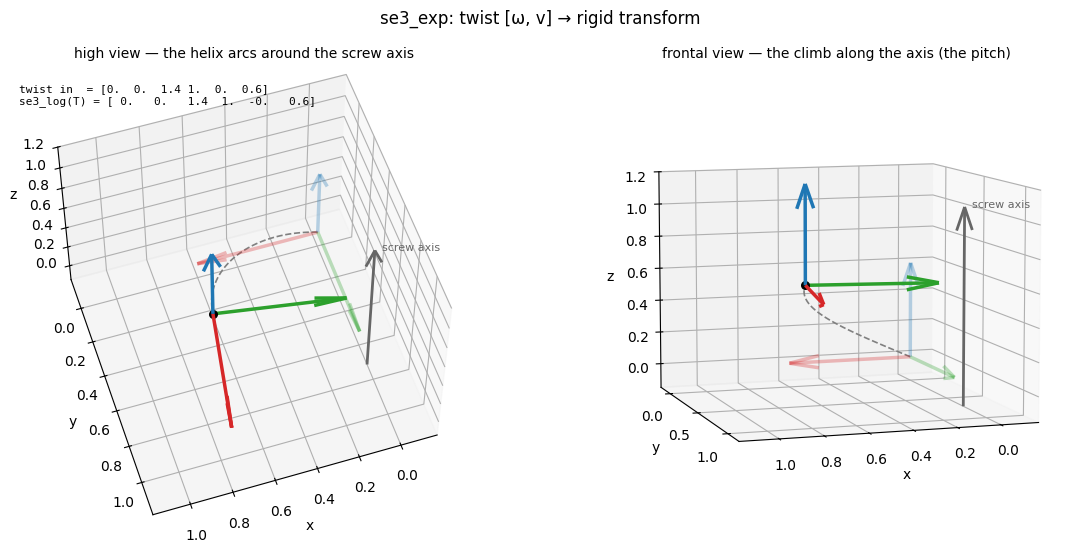

In [57]:
twist = np.array([0.0, 0.0, 1.4, 1.0, 0.0, 0.6])     # ω about z, with translation
gp.fig_se3_exp(twist)

**`screw_interpolate`** — the SE(3) analogue of SLERP: it blends two rigid transforms along the constant screw connecting them, rotating and translating together. `t = 0` returns T₀ and `t = 1` returns T₁; an array of `t`s broadcasts, so the single call below yields all seven triads at once. They fade in with `t` — T₀ faintest, T₁ boldest — and the dashed curve traces the origin's screw arc between them.

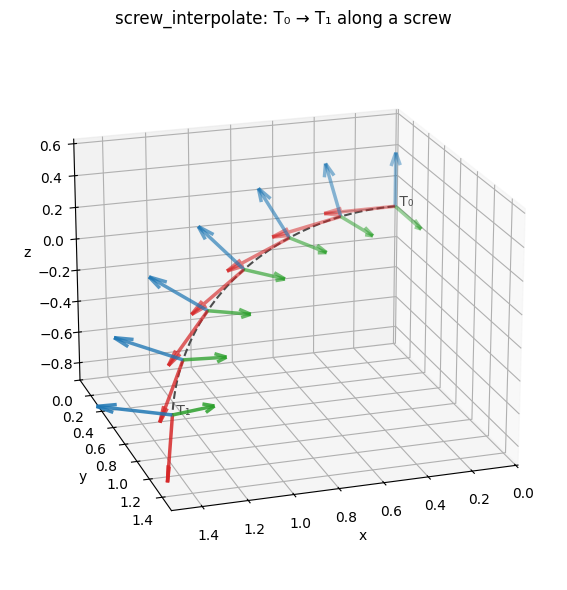

In [58]:
T0 = np.eye(4)
T1 = rotations.se3_exp(np.array([0.3, 1.2, 0.6, 2.0, 1.0, 0.5]))
ts = np.linspace(0, 1, 7)
frames = rotations.screw_interpolate(T0, T1, ts)     # (7, 4, 4): t=0 → T₀ … t=1 → T₁
gp.fig_screw_interpolate(frames, ts)

**`relative_transform`** — the pose of one body segment in another's local frame (the geometry→SE(3) bridge). The two arm bones are drawn; the printed twist is the relative transform `se3_log(T_upper⁻¹ T_fore)`. Segment frames are completed with a fixed world reference direction, which keeps the features smooth over time but ties them to global heading — root-align the motion (e.g. `harmonize`) before comparing these features across clips.

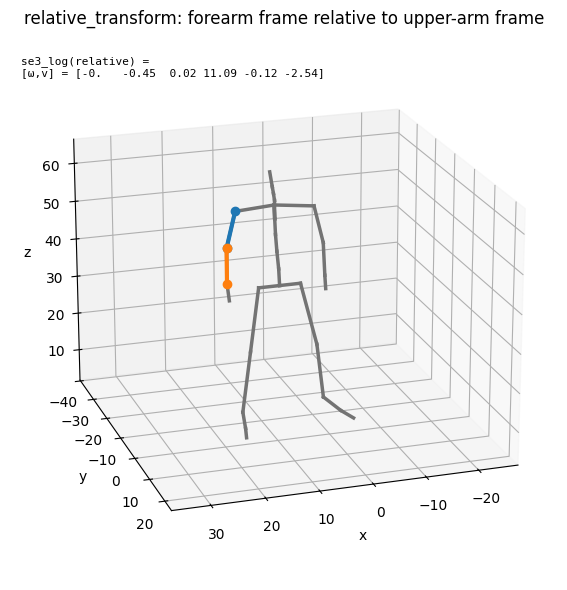

In [59]:
upper = np.stack([P[idx("RightArm")], P[idx("RightForeArm")]])
fore = np.stack([P[idx("RightForeArm")], P[idx("RightHand")]])
twist = rotations.se3_log(rotations.relative_transform(upper[None], fore[None])[0])
gp.fig_relative_transform(bvh, FRAME, twist)

**`rotation_geodesic_distance`** — the shortest angular distance between two orientations. Left: two orientation triads and the angle between them. Right: the geodesic distance of the root's orientation at each frame from frame 0.

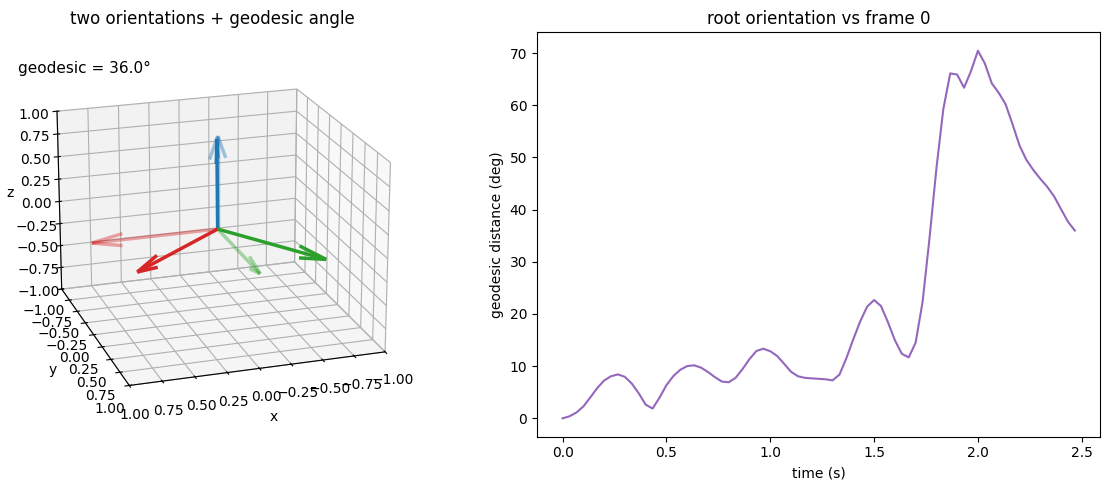

In [60]:
_, rotmats = bvh.to_rotmat()
root_R = rotmats[:, 0]
geo = np.degrees(rotations.rotation_geodesic_distance(
    np.broadcast_to(root_R[0], root_R.shape), root_R))
gp.fig_geodesic(root_R, geo, t)

## 11 · Signal — signal utilities

Array-pure numeric helpers, each shown on a small constructed signal where the effect is obvious.

**`finite_difference`** — the shared derivative operator. On a sine wave, the central and forward differences both track the analytic derivative (cosine); central is symmetric and more accurate.

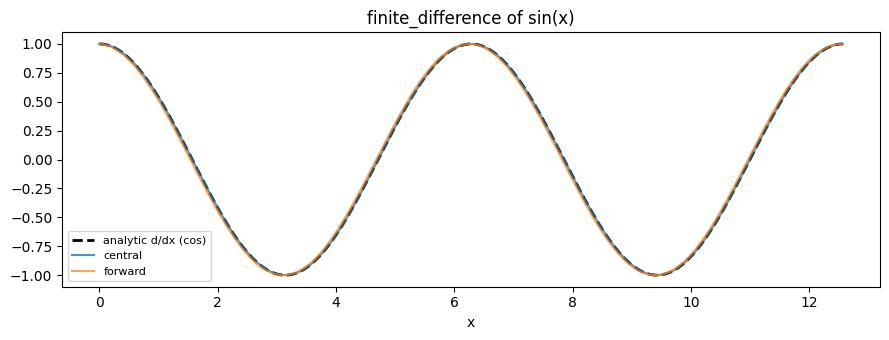

In [61]:
x = np.linspace(0, 4 * np.pi, 200)
h = x[1] - x[0]
d_central = signal.finite_difference(np.sin(x), h, stencil="central")
d_forward = signal.finite_difference(np.sin(x), h, stencil="forward")
gp.fig_finite_difference(x, d_central, d_forward)

**`temporal_stats`** & **`box_filter_smooth`** — left: a noisy signal with its mean ± std band, and skewness/kurtosis printed. Right: the same signal smoothed by a box (moving-average) filter.

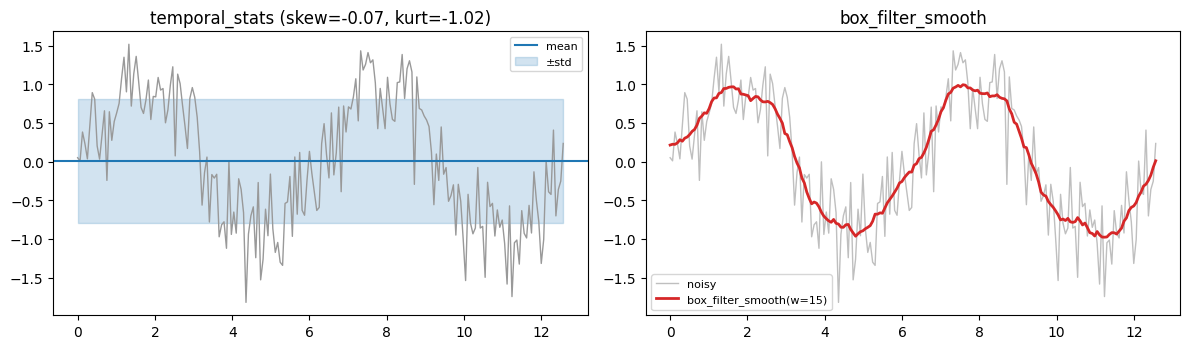

In [62]:
rng = np.random.default_rng(0)
noisy = np.sin(x) + 0.4 * rng.standard_normal(x.size)
st = signal.temporal_stats(noisy)
smoothed = signal.box_filter_smooth(noisy, window=15)
gp.fig_temporal_box(x, noisy, st, smoothed)

**`fft_magnitude` / `dominant_frequency`** — left: a signal mixing 3 Hz and 11 Hz, shown in time (first second). Right: its one-sided magnitude spectrum (`fft_magnitude`) resolves both components as peaks, and `dominant_frequency` picks the strongest — the red line lands on the taller 3 Hz peak, not merely any peak.

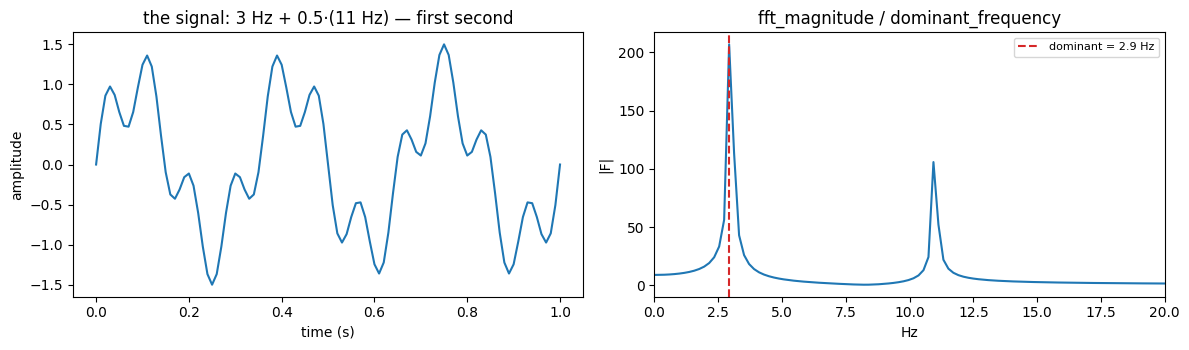

In [63]:
fsx, n = 100.0, 512
tx = np.arange(n) / fsx
mix = np.sin(2 * np.pi * 3 * tx) + 0.5 * np.sin(2 * np.pi * 11 * tx)
freqs, mag = signal.fft_magnitude(mix, fsx)
dom = signal.dominant_frequency(mix, fsx)
gp.fig_fft(tx, mix, freqs, mag, dom)

**`ramer_douglas_peucker`** — simplifies a curve, keeping only the points needed to preserve its shape within a tolerance. The noisy curve (grey) is reduced to a few vertices (red) that still capture its form.

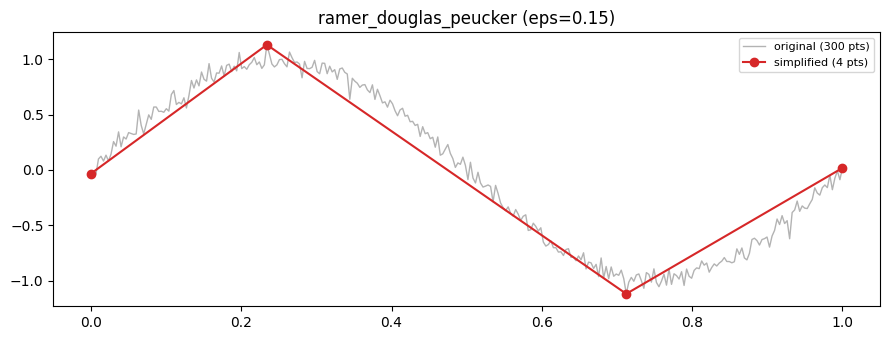

In [64]:
tc = np.linspace(0, 1, 300)
curve = np.stack([tc, np.sin(2 * np.pi * tc) + 0.05 * rng.standard_normal(tc.size)], 1)
simp = signal.ramer_douglas_peucker(curve, eps=0.15)
gp.fig_rdp(curve, simp, 0.15)

## 12 · Scale

**`relative_scale_factor`** — the least-squares uniform scale that best matches one skeleton to another. Here a skeleton (blue) and a 1.6× copy (orange) are shown; the recovered factor matches the original poses back together.

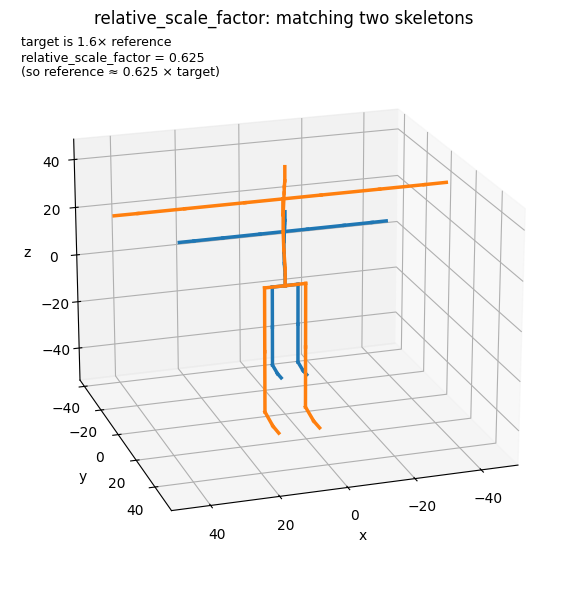

In [65]:
rest = bvh.rest_pose_positions()
factor = analysis.relative_scale_factor(rest, rest * 1.6)
gp.fig_relative_scale(bvh, factor, 1.6)

---
That is pybvh's visual surface — every operation, transform, descriptor, and utility that has a picture, each drawn so the picture explains the call. What has no natural picture (file I/O, batch loading, harmonization, pandas) lives in the [capability map](https://victors-67.github.io/pybvh/api/) instead. The array-pure kernels (`geometry.*`, the smoothness functions, the SE(3) math, `signal.*`) take plain NumPy arrays, so any of these visuals can be reproduced without a `Bvh` at all.